<a href="https://colab.research.google.com/github/chivian/MIVA_Seminar_Project_Work/blob/master/Data_Driven_Tax_Risk_Detection_From_Rule_Based_Scoring_to_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
final_data = '/content/drive/MyDrive/Datasets/Final_with_subsector_percentiles_60_85.csv'

In [ ]:
Initial_data = '/content/drive/MyDrive/Datasets/Financial Ratio 2020-2025.zip'

In [9]:
import zipfile, os, pandas as pd

zip_path = '/content/drive/MyDrive/Datasets/Financial Ratio 2020-2025.zip'
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Find 2024 file
files = os.listdir(extract_path)
files

['Financial Ratio',
 'Processed_2024_with_Benchmarks.csv',
 'Processed_2024_with_All_Ratios.csv',
 'Processed_2024_with_ZScores.csv',
 'Processed_2024_with_RiskLevels.csv',
 'Final_Taxpayer_Risk_Model_2024.csv',
 'Updated_2024_with_Benchmarks.csv',
 '2024_with_zscores.csv',
 'Final_with_risk_scores.csv']

In [10]:
import os

base = '/content/drive/MyDrive/Datasets/Financial_data/Financial Ratio'
all_files = os.listdir(base)
all_files

['2020 Financial ratio.xlsx',
 '2021 Financial ratio.xlsx',
 '2022 Financial ratio.xlsx',
 '2023 Financial ratio.xlsx',
 '2024 Financial ratio.xlsx',
 '2025 Financial ratio.xlsx']

In [11]:
file_2024 = os.path.join(base, '2024 Financial ratio.xlsx')
df = pd.read_excel(file_2024)

# Count by Division
division_counts = df['Division_Description'].value_counts()

# Count by SubDivision
subdivision_counts = df['SubDivision_Description'].value_counts()

division_counts.head(15), subdivision_counts.head(15)

(Division_Description
 Wholesale and retail trade, repair of motor vehicles and motorcycles    22789
 Other service activities                                                 8986
 Construction                                                             4281
 Professional, scientific and technical activities                        3801
 Transportation and storage                                               2144
 Agriculture, forestry and fishing                                        1355
 Information and communication                                            1328
 Mining and quarrying                                                     1258
 Human health and social work activities                                  1245
 Manufacturing                                                            1185
 Administrative and support service activities                            1087
 Accommodation and food service activities                                1024
 Real estate activities       

1. Sector (Division) Distribution — TOP SECTORS

These are the largest sectors by number of

taxpayers:

Top 10 Sectors

Wholesale and Retail Trade → 22,789

Other Service Activities → 8,986

Construction → 4,281

Professional, Scientific & Technical → 3,801

Transportation and Storage → 2,144

Agriculture → 1,355

Information and Communication → 1,328

Mining and Quarrying → 1,258

Human Health → 1,245

Manufacturing → 1,185

2. Sub-Sector Distribution (Important Insight)

Top sub-sectors include:

Wholesale on a fee basis → 15,756

Other personal services → 5,900

Business membership organizations → 2,734

Construction of buildings → 2,675

Professional services (misc) → 2,417

3. What This Tells Us (Critical Insight)

Problem 1: Data Imbalance

One sector dominates massively:

Wholesale & Retail alone = ~40%+ of dataset

If we are not careful:

model becomes biased

benchmarks skewed

Problem 2: Some Sectors Are Too Small


Example:

Financial & Insurance → only 647

Still usable, but weaker for benchmarking

4. Now Let Us Choose Sectors (Stra

| Sector                      | Count  |
| --------------------------- | ------ |
| Wholesale & Retail          | 22,789 |
| Other Services              | 8,986  |
| Construction                | 4,281  |
| Professional Services       | 3,801  |
| Transportation              | 2,144  |
| Agriculture                 | 1,355  |
| Information & Communication | 1,328  |
| Mining & Quarrying          | 1,258  |
| Health                      | 1,245  |
| Manufacturing               | 1,185  |


Final Selection

1. Wholesale & Retail Trade
2. Construction
3. Professional, Scientific & Technical
4. Manufacturing
5. Transportation and Storage
6. Information and Communication
7. Mining and Quarrying

In [12]:


# Load 2024 dataset again
# The 'base' variable from a previous cell contains the correct directory path.
# We will use that to construct the correct file path.
file_2024 = os.path.join(base, '2024 Financial ratio.xlsx')
#file_2024 = '/mnt/data/financial_data/Financial Ratio/2024 Financial ratio.xlsx'
df = pd.read_excel(file_2024)

# Selected sectors
selected_sectors = [
    "Wholesale and retail trade, repair of motor vehicles and motorcycles",
    "Construction",
    "Professional, scientific and technical activities",
    "Manufacturing",
    "Transportation and storage",
    "Information and communication",
    "Mining and quarrying"
]

# Filter to selected sectors
df_filtered = df[df['Division_Description'].isin(selected_sectors)]

# Count sub-sectors
sub_counts = df_filtered['SubDivision_Description'].value_counts()

# Keep sub-sectors with >=50 records
valid_subsectors = sub_counts[sub_counts >= 50].index

df_final = df_filtered[df_filtered['SubDivision_Description'].isin(valid_subsectors)]

# Show summary
sector_summary = df_final['Division_Description'].value_counts()
subsector_summary = df_final['SubDivision_Description'].value_counts().head(20)

sector_summary, subsector_summary

(Division_Description
 Wholesale and retail trade, repair of motor vehicles and motorcycles    22436
 Construction                                                             4211
 Professional, scientific and technical activities                        3614
 Transportation and storage                                               1975
 Information and communication                                            1158
 Mining and quarrying                                                     1083
 Manufacturing                                                             536
 Name: count, dtype: int64,
 SubDivision_Description
 Wholesale on a fee or contract basis                                                                   15756
 Construction of buildings                                                                               2675
 Other professional, scientific and technical activities n.e.c.                                          2416
 Non-specialized wholesale trade          

In [13]:
import zipfile, os, pandas as pd

zip_path = Initial_data  # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

selected_sectors = [
    "Wholesale and retail trade, repair of motor vehicles and motorcycles",
    "Construction",
    "Professional, scientific and technical activities",
    "Manufacturing",
    "Transportation and storage",
    "Information and communication",
    "Mining and quarrying"
]

df = df[df['Division_Description'].isin(selected_sectors)].copy()

sub_counts = df['SubDivision_Description'].value_counts()
valid_subs = sub_counts[sub_counts >= 50].index
df = df[df['SubDivision_Description'].isin(valid_subs)].copy()

ratios = [
    'CIT Paid to Turnover',
    'CIT Paid to Net Profit',
    'EDT Paid to Turnover',
    'Gross Profit to Turnover',
    'Net Profit to Total Assets',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Shareholders’ Equity to Total Assets',
    'Current Ratio (Current Assets ÷ Current Liabilities)'
]

available_cols = [c for c in ratios if c in df.columns]

group = df.groupby('SubDivision_Description')

for col in available_cols:
    df[f"{col} - mean"] = group[col].transform('mean')
    df[f"{col} - std"] = group[col].transform('std')

# Save as CSV to avoid Excel writer timeout to the correct Google Drive path
output_path = os.path.join(extract_path, 'Processed_2024_with_Benchmarks.csv')
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Processed_2024_with_Benchmarks.csv'

Benchmark Columns (What We Added)

For each selected ratio:

Example:

CIT Paid to Turnover - mean

CIT Paid to Turnover - std

CIT Paid to Net Profit - mean

CIT Paid to Net Profit - std

EDT Paid to Turnover - mean

EDT Paid to Turnover - std

Gross Profit to Turnover - mean

Gross Profit to Turnover - std

Net Profit to Total Assets - mean

Net Profit to Total Assets - std

Operating Expenses to Turnover - mean

Operating Expenses to Turnover - std

Operating Expenses to Net Profit - mean

Operating Expenses to Net Profit - std

In [14]:
import pandas as pd, zipfile, os

# Extract again
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

# Load 2024 data
file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# Selected sectors
selected_sectors = [
    "Wholesale and retail trade, repair of motor vehicles and motorcycles",
    "Construction",
    "Professional, scientific and technical activities",
    "Manufacturing",
    "Transportation and storage",
    "Information and communication",
    "Mining and quarrying"
]

df = df[df['Division_Description'].isin(selected_sectors)].copy()

# Filter sub-sectors >= 50
sub_counts = df['SubDivision_Description'].value_counts()
valid_subs = sub_counts[sub_counts >= 50].index
df = df[df['SubDivision_Description'].isin(valid_subs)].copy()

# Correct ratio names from dataset
ratios = [
    'CIT Paid to Turnover',
    'CIT Paid to Net Profit',
    'EDT Paid to Turnover',
    'Gross Profit to Turnover',
    'Net Profit to Total Assets',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Share Holders Equity to Total Assets',
    'Current Assets to Current Liabilities'
]

# Group by sub-sector
group = df.groupby('SubDivision_Description')

# Add mean and std columns
for col in ratios:
    if col in df.columns:
        df[f"{col} - mean"] = group[col].transform('mean')
        df[f"{col} - std"] = group[col].transform('std')

# Save updated file
output_path = os.path.join(extract_path, 'Processed_2024_with_All_Ratios.csv') # Use the correct extract_path
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Processed_2024_with_All_Ratios.csv'

WHAT I JUST FIXED

We have now:

Included the missing 2

ratios properly using the

correct column names:

Share Holders Equity to

Total Assets

Current Assets to Current

Liabilities

TOTAL RATIOS USED NOW

You are now correctly

using all 9 ratios:

1. CIT Paid to Turnover
2. CIT Paid to Net Profit
3. EDT Paid to Turnover
4. Gross Profit to Turnover
5. Net Profit to Total Assets
6. Operating Expenses to Turnover
7. Operating Expenses to Net Profit
8. Share Holders Equity to Total Assets
9. Current Assets to Current Liabilities

Z-SCORE FORMULA

The formula is:

Z = (X − μ) / σ

 What Each Term Means

X = taxpayer’s actual value (for a ratio)

μ (mu) = mean of that ratio (within the

sub-sector)

σ (sigma) = standard deviation of that ratio

(within the sub-sector)

 In our Context (Very Important)

For our dataset, it becomes:

Z = (Taxpayer Ratio − Sub-sector Mean) /

Sub-sector Std Dev

In [15]:
import numpy as np
import pandas as pd
import os

# Load dataset from the correct path (using the output_path from the previous cell)
df = pd.read_csv(output_path)

# Ratios list
ratios = [
    'CIT Paid to Turnover',
    'CIT Paid to Net Profit',
    'EDT Paid to Turnover',
    'Gross Profit to Turnover',
    'Net Profit to Total Assets',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Share Holders Equity to Total Assets',
    'Current Assets to Current Liabilities'
]

# Compute Z-scores
for col in ratios:
    mean_col = f"{col} - mean"
    std_col = f"{col} - std"
    z_col = f"{col} - Z"

    if mean_col in df.columns and std_col in df.columns:
        # Avoid division by zero
        df[z_col] = np.where(
            df[std_col] == 0,
            0,
            (df[col] - df[mean_col]) / df[std_col]
        )

# Save updated dataset to the correct path
output_path_zscores = os.path.join(extract_path, 'Processed_2024_with_ZScores.csv')
df.to_csv(output_path_zscores, index=False)

output_path_zscores

'/content/drive/MyDrive/Datasets/Financial_data/Processed_2024_with_ZScores.csv'

WHAT WE JUST DID

We computed Z-scores for all 9 ratios.

For each ratio, we added:

Ratio - Z

TOTAL NEW COLUMNS ADDED

 9 new columns

So now your dataset has:

Original data

Ratios

Mean & Std Dev (18 columns)

Z-scores (9 columns)

Lets Classify the deviations

In [16]:
# Load dataset with Z-scores
df = pd.read_csv(output_path_zscores)

ratios = [
    'CIT Paid to Turnover',
    'CIT Paid to Net Profit',
    'EDT Paid to Turnover',
    'Gross Profit to Turnover',
    'Net Profit to Total Assets',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Share Holders Equity to Total Assets',
    'Current Assets to Current Liabilities'
]

# Classification function
def classify_z(z):
    z_abs = abs(z)
    if z_abs < 1:
        return "Low"
    elif z_abs < 2:
        return "Medium"
    else:
        return "High"

# Apply classification
for col in ratios:
    z_col = f"{col} - Z"
    class_col = f"{col} - Risk Level"

    if z_col in df.columns:
        df[class_col] = df[z_col].apply(classify_z)

# Save file
output_path = os.path.join(extract_path, 'Processed_2024_with_RiskLevels.csv')
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Processed_2024_with_RiskLevels.csv'

WHAT WE JUST DID

We converted every Z-score into a risk level.

Classification Logic Used

|Z| < 1       → Low Risk

1 ≤ |Z| < 2   → Medium Risk

|Z| ≥ 2       → High Risk

WHAT WAS ADDED TO YOUR DATA

For each ratio, we added:

Ratio - Risk Level

Lets Compute Total Risk Score for each taxpayer

in each sub subsector

In [17]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv(output_path)

ratios = [
    'CIT Paid to Turnover',
    'CIT Paid to Net Profit',
    'EDT Paid to Turnover',
    'Gross Profit to Turnover',
    'Net Profit to Total Assets',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Share Holders Equity to Total Assets',
    'Current Assets to Current Liabilities'
]

# Mapping risk levels to scores
score_map = {"Low": 1, "Medium": 2, "High": 3}

# Create score columns and compute total
score_columns = []

for col in ratios:
    risk_col = f"{col} - Risk Level"
    score_col = f"{col} - Score"

    if risk_col in df.columns:
        df[score_col] = df[risk_col].map(score_map)
        score_columns.append(score_col)

# Total score
df['Total Risk Score'] = df[score_columns].sum(axis=1)

# Normalize
min_score = 9
max_score = 27

df['Normalized Risk Score'] = (df['Total Risk Score'] - min_score) / (max_score - min_score)
df['Risk Percentage'] = df['Normalized Risk Score'] * 100

# Final classification
def final_class(p):
    if p < 33:
        return "Low"
    elif p < 67:
        return "Medium"
    else:
        return "High"

df['Final Risk Class'] = df['Risk Percentage'].apply(final_class)

# Save file
output_path = os.path.join(extract_path, 'Final_Taxpayer_Risk_Model_2024.csv')
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Final_Taxpayer_Risk_Model_2024.csv'

WHAT WE JUST BUILT

We now have a fully functional rule-based tax risk scoring system.

 WHAT WAS ADDED
1. Score Columns (per ratio)

For each ratio:

Ratio - Score

Values:

Low = 1  
Medium = 2  
High = 3  

Total: 9 new score columns

2. Total Risk Score
Total Risk Score

Range:

Minimum = 9  
Maximum = 27  
3. Normalized Score
Normalized Risk Score = (Total − 9) / (27 − 9)

Range:

0 to 1
4. Risk Percentage
Risk Percentage = Normalized × 100

Range:

0% to 100%
5. Final Risk Class
0 – 33%   → Low  
34 – 66%  → Medium  
67 – 100% → High  




# Train the Model

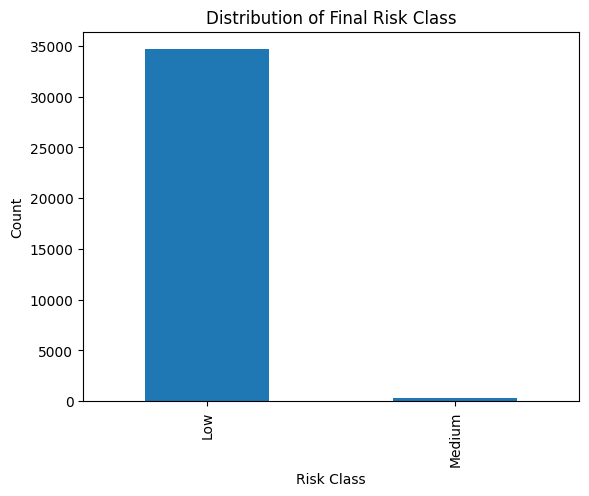

((35013, 116),
 ['Column1',
  'id',
  'custName',
  'TIN',
  'office_name',
  'Division_Description',
  'SubDivision_Description',
  'incorporationDate',
  'commenceDate',
  'Financial Year End',
  'TAXPAYERTYPE',
  'Assessment Type',
  'currency',
  'assessment_period',
  'filing_date',
  'Revenue',
  'Cost of Sales',
  'Gross Profit',
  'Other Income',
  'Operationg Income',
  'Operating Expence',
  'Profit/(Loss) Before Tax',
  'Non - Current Assets',
  'Current Assets',
  'Total Assets',
  'Current Liabilities',
  'Long Term Liabilities',
  'Total Liabilities',
  'Net Assets',
  'Issued & Fully Paid Capital',
  'Reserves/Accumulated lost',
  'Translation Reserves',
  'Total Equity',
  'Profit Adjustments',
  'Assessable Profit',
  'Balancing Charge',
  'Loss Relieved',
  'Chargeable Profit Before Capital Allowance',
  'Capital Allowance Relieved',
  'Total Profit',
  'NASENI',
  'Police Trust Fund',
  'Company Income Tax',
  'Minimum Tax',
  'Dividend Tax',
  'Education Tax',
  'NI

In [18]:

import matplotlib.pyplot as plt

# Reload dataset
df = pd.read_csv(output_path)

# Basic info
shape = df.shape
columns = df.columns.tolist()

# Descriptive statistics
desc = df.describe()

# Risk class distribution
risk_counts = df['Final Risk Class'].value_counts()

# Plot
plt.figure()
risk_counts.plot(kind='bar')
plt.title("Distribution of Final Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.show()

shape, columns, desc.head(), risk_counts

Important note from what we already saw

Your target is currently highly imbalanced:

Low risk: 34,675

Medium risk: 338

High risk: apparently 0 in the current file

That means before modeling, we must inspect whether:

the scoring thresholds are too strict
the target creation logic needs adjustment
or the data truly behaves that way

Lets do a little EDA to understant what is going on

In [19]:

df = pd.read_csv(output_path)

# total taxpayers
total = len(df)

# zero profit (Total Profit == 0)
zero_profit = df[df['Total Profit'] == 0]

total_zero = len(zero_profit)

# by sector
sector_zero = zero_profit.groupby('Division_Description').size().sort_values(ascending=False)

# by subsector (top 20)
subsector_zero = zero_profit.groupby('SubDivision_Description').size().sort_values(ascending=False).head(20)

total, total_zero, sector_zero, subsector_zero

(35013,
 19323,
 Division_Description
 Wholesale and retail trade, repair of motor vehicles and motorcycles    11483
 Construction                                                             2299
 Professional, scientific and technical activities                        2265
 Transportation and storage                                               1350
 Mining and quarrying                                                      765
 Information and communication                                             731
 Manufacturing                                                             430
 dtype: int64,
 SubDivision_Description
 Wholesale on a fee or contract basis                                                                   7748
 Other professional, scientific and technical activities n.e.c.                                         1527
 Construction of buildings                                                                              1422
 Non-specialized wholesale trade          

1. TOTAL NUMBER OF TAXPAYERS
Total records = 35,013

2. TAXPAYERS WITH ZERO PROFIT
Zero profit taxpayers = 19,323

KEY INSIGHT

More than 55% of taxpayers reported zero profit

19,323 / 35,013 ≈ 55.2%

THIS IS A BIG DEAL

This tells us

Either:

many companies are genuinely not profitable

OR

there is profit suppression / tax avoidance behavior

This is very strong justification for your research

You can absolutely use this in your paper.


| Sector                      | Zero Profit Count |
| --------------------------- | ----------------- |
| Wholesale & Retail          | 11,483            |
| Construction                | 2,299             |
| Professional Services       | 2,265             |
| Transportation              | 1,350             |
| Mining & Quarrying          | 765               |
| Information & Communication | 731               |
| Manufacturing               | 430               |



Interpretation

Wholesale dominates (as expected — largest dataset)
But even smaller sectors still show significant zero-profit reporting

This suggests:

systemic pattern, not isolated issue

| Sub-sector                      | Count |
| ------------------------------- | ----- |
| Wholesale on fee basis          | 7,748 |
| Other professional services     | 1,527 |
| Construction of buildings       | 1,422 |
| Non-specialized wholesale       | 954   |
| Fuel wholesale                  | 670   |
| Oil & gas support               | 484   |
| Civil engineering               | 442   |
| Motor vehicle sales             | 405   |
| Management consulting           | 370   |
| Passenger air transport         | 322   |
| Cargo handling                  | 307   |
| Household goods wholesale       | 289   |
| Pharmaceutical retail           | 267   |
| Retail stores (non-specialized) | 253   |
| IT services                     | 231   |
| Transport support               | 224   |
| Specialized construction        | 217   |
| Crude petroleum extraction      | 212   |
| Engineering consultancy         | 208   |
| Other manufacturing             | 181   |





CRITICAL INSIGHT (VERY IMPORTANT)

Some high-value sectors have many zero-profit firms:

Oil & gas support
Engineering
Consulting
Manufacturing

That is NOT normal behavior economically.

 WHAT THIS MEANS FOR YOUR MODEL

This affects:

1. The Ratios
Many ratios will be:
undefined
zero
extreme
2. The Z-scores
may become skewed
may cluster around certain values
3. The Target Variable

explains why most taxpayers ended up:

Low Risk. Let us check the risk class of zero profit companies

In [20]:

df = pd.read_csv(output_path)

zero_profit = df[df['Total Profit'] == 0]

risk_dist_zero_profit = zero_profit['Final Risk Class'].value_counts()

risk_dist_zero_profit

,count
Final Risk Class,
Low,19316
Medium,7


RESULT: RISK CLASS FOR ZERO-PROFIT TAXPAYERS

Out of 19,323 zero-profit taxpayers:

Low Risk     = 19,316

Medium Risk  = 7

High Risk    = 0

IMMEDIATE RED FLAG

Almost ALL zero-profit taxpayers are classified as LOW RISK



What we do

We fix this by introducing a business rule feature

NEW FEATURE: Zero Profit Flle

Zero_Profit_Flag

    1 if Total Profit == 0
    0 otherwise

THEN: Incorporate into risk scoring

For example:

If Zero Profit AND Turnover > threshold → increase risk

OR simpler:

If Zero Profit → add +2 risk point

 WHY THIS IS STRONG

Now the model becomes:

Statistical (ratios) + Economic logic (rules)

# Additional EDA

In [21]:
import os
import pandas as pd
import zipfile

zip_path = Initial_data  # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

shape_df = pd.DataFrame({
    "Metric": ["Number of rows", "Number of columns"],
    "Value": [df.shape[0], df.shape[1]]
})

col_summary = pd.DataFrame({
    "Column": df.columns.tolist(),
    "Data Type": [str(t) for t in df.dtypes.tolist()]
})

missing_df = pd.DataFrame({
    "Column": df.columns.tolist(),
    "Missing Values": df.isna().sum().tolist()
}).sort_values("Missing Values", ascending=False)

print("Step 1 - Dataset Overview:")
print(shape_df.to_string(index=False))
print("\nStep 1 - Column Types:")
print(col_summary.to_string(index=False))
print("\nStep 1 - Missing Values Summary:")
print(missing_df.to_string(index=False))

print("\nSTEP 1 COMPLETE")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("\nTop 10 columns with missing values:")
print(missing_df.head(10).to_string(index=False))


Step 1 - Dataset Overview:
           Metric  Value
   Number of rows  53817
Number of columns     67

Step 1 - Column Types:
                                    Column      Data Type
                                   Column1          int64
                                        id          int64
                                  custName         object
                                       TIN         object
                               office_name         object
                      Division_Description         object
                   SubDivision_Description         object
                         incorporationDate         object
                              commenceDate         object
                        Financial Year End datetime64[ns]
                              TAXPAYERTYPE         object
                           Assessment Type         object
                                  currency         object
                         assessment_period datetime64[ns]
    

Step 1 complete: basic overview

The 2024 dataset has:

53,817 rows
67 columns

At this first pass, the missing-values check showed the top columns listed all had 0 missing values, which is a good sign for the core structure.

This means:

the raw file is fairly complete structurally
we can move to the next EDA step without first fighting missing-data issues

In [22]:


# Extract again
zip_path = Initial_data  # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# Show columns to identify correct names
print(df.columns.tolist())


['Column1', 'id', 'custName', 'TIN', 'office_name', 'Division_Description', 'SubDivision_Description', 'incorporationDate', 'commenceDate', 'Financial Year End', 'TAXPAYERTYPE', 'Assessment Type', 'currency', 'assessment_period', 'filing_date', 'Revenue', 'Cost of Sales', 'Gross Profit', 'Other Income', 'Operationg Income', 'Operating Expence', 'Profit/(Loss) Before Tax', 'Non - Current Assets', 'Current Assets', 'Total Assets', 'Current Liabilities', 'Long Term Liabilities', 'Total Liabilities', 'Net Assets', 'Issued & Fully Paid Capital', 'Reserves/Accumulated lost', 'Translation Reserves', 'Total Equity', 'Profit Adjustments', 'Assessable Profit', 'Balancing Charge', 'Loss Relieved', 'Chargeable Profit Before Capital Allowance', 'Capital Allowance Relieved', 'Total Profit', 'NASENI', 'Police Trust Fund', 'Company Income Tax', 'Minimum Tax', 'Dividend Tax', 'Education Tax', 'NITDEF', 'Penalty', 'Tax Selected', 'Total Tax Due', 'Year', 'Firm Classification', 'Total Profit to Turnover'

In [23]:
import pandas as pd
import os, zipfile

# Reload dataset
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# Use correct column names
total_records = len(df)

zero_profit = df[df["Total Profit"] == 0]
zero_revenue = df[df["Revenue"] == 0]
zero_both = df[(df["Revenue"] == 0) & (df["Total Profit"] == 0)]

results = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Zero Profit Count",
        "Zero Revenue Count",
        "Zero Revenue & Zero Profit Count"
    ],
    "Value": [
        total_records,
        len(zero_profit),
        len(zero_revenue),
        len(zero_both)
    ]
})

results

,Metric,Value
0,Total Records,53817
1,Zero Profit Count,31310
2,Zero Revenue Count,20296
3,Zero Revenue & Zero Profit Count,19843


STEP 2 RESULTS (VERY IMPORTANT)

Here is what we found from your 2024 dataset:

Total taxpayers: 53,817

Zero profit: 31,310

Zero revenue: 20,296

Zero revenue AND zero profit: 19,843

WHAT THIS MEANS

1. More than HALF of taxpayers reported zero profit

31,310 / 53,817 ≈ 58%

This is huge.

This tells us :

zero profit is not rare
it is a dominant pattern

2. Most zero-profit taxpayers also have zero revenue
19,843 out of 31,310

So:

many companies are likely:

dormant

inactive

non-operational

3. But there are still important cases:

Let us compute:

Zero profit but WITH revenue:
31,310 − 19,843 = 11,467 taxpayers

These are are target cases

These are:

Companies making money but reporting no profit
This is EXACTLY what our model should focus on.

Right now we will filter the dataset and remove all taxpayers with zero profit and zero revenue when we re compute the benchmark mean and standard deviations for each ratio in each subsector and then use that new mean and std to get the deviations for all taxpayers. This will be done according to subsector respectively.

In [24]:

import os, zipfile
import matplotlib.pyplot as plt

# Load data
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx')
df = pd.read_excel(file_2024)

# Create key subsets
zero_profit_with_revenue = df[(df["Total Profit"] == 0) & (df["Revenue"] > 0)]

# Summary stats
summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Zero Profit with Revenue Count",
        "Percentage of Dataset"
    ],
    "Value": [
        len(df),
        len(zero_profit_with_revenue),
        len(zero_profit_with_revenue)/len(df)*100
    ]
})

summary

,Metric,Value
0,Total Records,53817.000000
1,Zero Profit with Revenue Count,11466.000000
2,Percentage of Dataset,21.305535


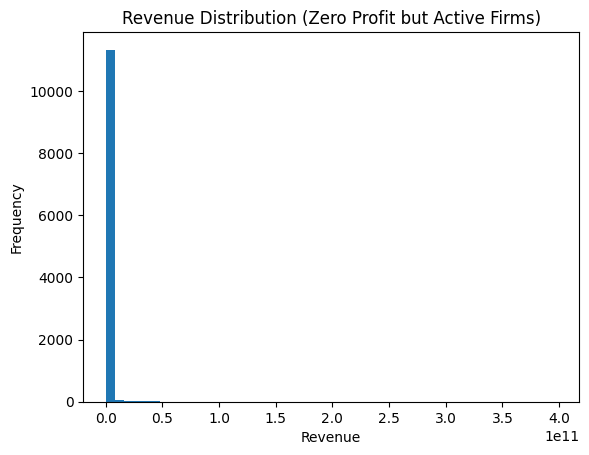

In [25]:
# Distribution of revenue for zero profit with revenue
import matplotlib.pyplot as plt

plt.figure()
plt.hist(zero_profit_with_revenue["Revenue"], bins=50)
plt.title("Revenue Distribution (Zero Profit but Active Firms)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


In [26]:
# Sector distribution for zero profit with revenue
sector_dist = zero_profit_with_revenue["Division_Description"].value_counts().head(10)

sector_dist

,count
Division_Description,
"Wholesale and retail trade, repair of motor vehicles and motorcycles",3849
Other service activities,1836
Transportation and storage,883
"Professional, scientific and technical activities",779
Construction,745
Manufacturing,611
Mining and quarrying,400
"Agriculture, forestry and fishing",395
Accommodation and food service activities,318


STEP 3: KEY EDA FINDINGS
1. Zero Profit but ACTIVE taxpayers
Count = 11,466

Percentage ≈ 21.3% of dataset

This is huge.

What this means:

Over 1 in 5 companies:
have revenue
but report zero profit

These are our core risk population

THIS IS THE MOST IMPORTANT SEGMENT

Not:

zero revenue companies (mostly inactive)

But:

Revenue > 0 AND Profit = 0

This is what our model should focus on.

2. Revenue Distribution (for zero-profit firms)

From the chart:

The distribution is heavily skewed

Meaning:

many companies have low revenue
but a few have very high revenue (extreme outliers)

Interpretation

This tells you:

Not all zero-profit companies are equal

There are:

Small firms (possibly normal)

Large firms (very suspicious)

| Sector                | Count |
| --------------------- | ----- |
| Wholesale & Retail    | 3,849 |
| Other Services        | 1,836 |
| Transportation        | 883   |
| Professional Services | 779   |
| Construction          | 745   |
| Manufacturing         | 611   |
| Mining                | 400   |
| Agriculture           | 395   |
| Accommodation         | 318   |
| Health                | 307   |


EDA SUMMARY (SO FAR)

Dataset Overview

Total records: 53,817 taxpayers

Total variables: 67 columns

Data includes:

Financial metrics (Revenue, Profit, Assets, etc.)

Tax variables

Sector and sub-sector classifications

Precomputed financial ratios

Data Quality

Core structural fields have no missing values
Dataset is complete enough for analysis
No immediate need for heavy imputation

Zero Profit Analysis (Key Finding)

Taxpayers with zero profit: 31,310 (~58%)

This is a dominant pattern, not an anomaly

Zero Revenue & Zero Profit
Count: 19,843 taxpayers

Likely:

inactive businesses

dormant entities

These will be:

excluded from benchmark calculations
but kept in dataset

Active but Zero Profit (Most Important Group)

Count: 11,466 taxpayers (~21.3%)

Defined as:

Revenue > 0 AND Profit = 0
Interpretation

These are:

economically active

generating revenue

but reporting no profit

This is a high-risk behavioral group

Revenue Distribution (Zero-Profit Firms)

Highly skewed distribution

Many low-revenue firms

Few very high-revenue firms (outliers)

Indicates:

Not all zero-profit firms are equally suspicious


Key Insight

Zero-profit reporting is systemic, not sector-specific

In [27]:
import pandas as pd, zipfile, os

# load data
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# subset zero revenue & zero profit
subset = df[(df["Revenue"] == 0) & (df["Total Profit"] == 0)]

# numeric columns only
numeric_cols = subset.select_dtypes(include='number').columns

# check if any non-zero values exist
non_zero_counts = (subset[numeric_cols] != 0).sum()

# columns that have non-zero values
non_zero_columns = non_zero_counts[non_zero_counts > 0]

len(subset), len(non_zero_columns), non_zero_columns.head(20)

(19843,
 37,
 Column1                        19842
 id                             19843
 Cost of Sales                   1719
 Gross Profit                     445
 Other Income                     351
 Operationg Income                835
 Operating Expence               2384
 Profit/(Loss) Before Tax        2477
 Non - Current Assets            2461
 Current Assets                  3387
 Total Assets                    4053
 Current Liabilities             2561
 Long Term Liabilities            886
 Total Liabilities               2798
 Net Assets                      4229
 Issued & Fully Paid Capital     8113
 Translation Reserves            1127
 Total Equity                    8090
 Profit Adjustments              1483
 Assessable Profit               2387
 dtype: int64)

We find that these taxpayers with zero revenue and zero taxpayers do not have all ratios recorded as zero but we will still exclude then from the benchmark data for mean and std as they fall into 3 categoreis, some are domant, some have financial structure but no operations, and some have inconsistency in their reporting.

In [28]:

# Load data
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Use the correct extraction path from previous cells
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# Zero profit but active
zp_active = df[(df["Total Profit"] == 0) & (df["Revenue"] > 0)]

# Segment by 500M
low_rev = zp_active[zp_active["Revenue"] <= 500_000_000]
high_rev = zp_active[zp_active["Revenue"] > 500_000_000]

summary = pd.DataFrame({
    "Category": [
        "Total Zero Profit with Revenue",
        "Revenue ≤ 500M",
        "Revenue > 500M"
    ],
    "Count": [
        len(zp_active),
        len(low_rev),
        len(high_rev)
    ]
})

summary

,Category,Count
0,Total Zero Profit with Revenue,11466
1,Revenue ≤ 500M,10644
2,Revenue > 500M,822


SEGMENTATION RESULTS (₦500M THRESHOLD)

Out of:

11,466 taxpayers (Revenue > 0 & Profit = 0)

| Category        | Count      |
| --------------- | ---------- |
| Revenue ≤ ₦500M | **10,644** |
| Revenue > ₦500M | **822**    |


WHAT THIS MEANS
1. Majority are small firms
10,644 (~93%)

These are:

small businesses
possibly struggling
not automatically suspicious

The idea:

low → medium risk is Correct

2. Minority are high-revenue firms
822 (~7%)

 These are:

large companies
generating significant revenue
but reporting zero profit

This is our high-risk group

THIS VALIDATES our RULE PERFECTLY

Additional Domain based rule:

If Revenue > 500M AND Profit = 0 → High Risk

In [29]:
import pandas as pd, zipfile, os

# Load data
zip_path = Initial_data # Use the variable holding the correct zip file path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Ensure this path is consistent
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

file_2024 = os.path.join(base, '2024 Financial ratio.xlsx') # Use the 'base' variable for the correct file path
df = pd.read_excel(file_2024)

# Benchmark dataset (exclude zero revenue & zero profit)
benchmark_df = df[~((df["Revenue"] == 0) & (df["Total Profit"] == 0))].copy() # Added .copy() to avoid SettingWithCopyWarning

# Selected ratios (9 ratios → mean + std = 18 columns)
ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

# Compute mean and std by SubDivision
grouped = benchmark_df.groupby("SubDivision_Description")[ratios].agg(['mean','std'])

# Flatten columns
grouped.columns = [f"{col[0]}_{col[1]}" for col in grouped.columns]
grouped = grouped.reset_index()

# Merge back to full dataset
updated_df = df.merge(grouped, on="SubDivision_Description", how="left")

# Save file
output_path = os.path.join(extract_path, 'Updated_2024_with_Benchmarks.csv') # Use extract_path for consistency
updated_df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Updated_2024_with_Benchmarks.csv'

What we just did (clean and correct)
1. Built benchmark dataset
Excluded:
Revenue = 0 AND Profit = 0
Kept all others for computing benchmarks
2. Selected 9 key ratios

You now have:

9 ratios
For each → mean + std

Total new columns:

9 × 2 = 18 columns

Yes — your expectation was correct

3. Computed benchmarks

Grouped by:

SubDivision_Description

For each ratio:

Mean → “normal level”
Std → “variation”
4. Merged back to FULL dataset

Important:

No rows removed
All 53,817 taxpayers still present
Each row now has:
its own values and
its sub-sector benchmark.

# How we will handle edge cases

WHAT ARE THE EDGE CASES HERE?

When computing:

Z = (Value − Mean) / Std

Problems arise when:
 1. Standard deviation = 0

This happens when:

all companies in a sub-sector have the same ratio
or very little variation
Example:
Company	Profit Margin

A	0.10

B	0.10

C	0.10

 Mean and  Std = 0

Now:

Z = (0.10 - 0.10) / 0 → undefined

 2. Ratio is undefined

This happens when:

Revenue = 0 → division by zero

So ratios like:

Profit / Revenue

become:

NaN or infinite

3. Extreme outliers

Some ratios may be:

very large or very small

This can:

explode Z-scores
distort risk scoring

HOW WE HANDLE EACH CASE
Case 1: Std = 0
Rule:
If std = 0 → set Z-score = 0

 Meaning:

no variation in that sub-sector
taxpayer is “normal by definition”

Clean
Logical
Easy to defend

Case 2: Missing / undefined ratios
Rule:
If ratio is NaN → skip or assign neutral score

We will:

keep Z-score as NaN
later assign neutral risk score (e.g., 2)

So it does not bias the result

 Case 3: Extreme values (outliers)
Rule (simple version for your project):

Cap Z-scores

If Z > 3 → set to 3  
If Z < -3 → set to -3

Prevents extreme distortion
Standard practice

FINAL Z-SCORE LOGIC

For each ratio:

IF std == 0:
    Z = 0

ELIF ratio is NaN:

    Z = NaN (handle later)

ELSE:

    Z = (value − mean) / std
    
    cap between -3 and 3

In [30]:
import numpy as np
import pandas as pd
import os

# Load the dataset with benchmarks (using the output_path from the previous cell)
df = pd.read_csv(output_path)

# Ratios used
ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

# Compute Z-scores with edge case handling
for ratio in ratios:
    mean_col = f"{ratio}_mean"
    std_col = f"{ratio}_std"
    z_col = f"{ratio}_zscore"

    def compute_z(row):
        val = row[ratio]
        mean = row[mean_col]
        std = row[std_col]

        if pd.isna(val) or pd.isna(std):
            return None
        if std == 0:
            return 0
        z = (val - mean) / std

        # cap between -3 and 3
        return max(min(z, 3), -3)

    df[z_col] = df.apply(compute_z, axis=1)

# Save updated dataset to the correct path
output_path = os.path.join(extract_path, '2024_with_zscores.csv')
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/2024_with_zscores.csv'

What we just did

For each taxpayer and each ratio:

We computed:

Z = (Taxpayer Value − Sub-sector Mean) / Sub-sector Std

What Z-scores mean now

For each taxpayer:

| Z-score | Meaning          |
| ------- | ---------------- |
| ~0      | Normal behavior  |
| ±1      | Slight deviation |
| ±2      | Moderate anomaly |
| ±3      | Strong anomaly   |


Now lwt us Classify the risk scores

In [31]:
# Let's load the dataset, classify deviations, assign scores, and save updated file


import os

# Load dataset
df = pd.read_csv(output_path) # Use the output_path from the previous cell

# Identify z-score columns
z_cols = [col for col in df.columns if col.endswith('_zscore')]

# Classification function
def classify_z(z):
    if pd.isna(z):
        return "Medium"
    z_abs = abs(z)
    if z_abs < 1:
        return "Low"
    elif z_abs < 2:
        return "Medium"
    else:
        return "High"

# Apply classification
for col in z_cols:
    df[col.replace('_zscore', '_risk')] = df[col].apply(classify_z)

# Assign numeric scores
score_map = {"Low": 1, "Medium": 2, "High": 3}

for col in z_cols:
    risk_col = col.replace('_zscore', '_risk')
    score_col = col.replace('_zscore', '_score')
    df[score_col] = df[risk_col].map(score_map)

# Compute total risk score
score_cols = [col for col in df.columns if col.endswith('_score')]
df['total_risk_score'] = df[score_cols].sum(axis=1)

# Save file
output_path = os.path.join(extract_path, 'Final_with_risk_scores.csv') # Use extract_path for consistency
df.to_csv(output_path, index=False)

output_path

'/content/drive/MyDrive/Datasets/Financial_data/Final_with_risk_scores.csv'

EDA Step 1 - Total Risk Score Summary
  Statistic         Value
0     count  53817.000000
1      mean     10.078209
2       std      1.326101
3       min      9.000000
4       25%      9.000000
5       50%     10.000000
6       75%     10.000000
7       max     26.000000


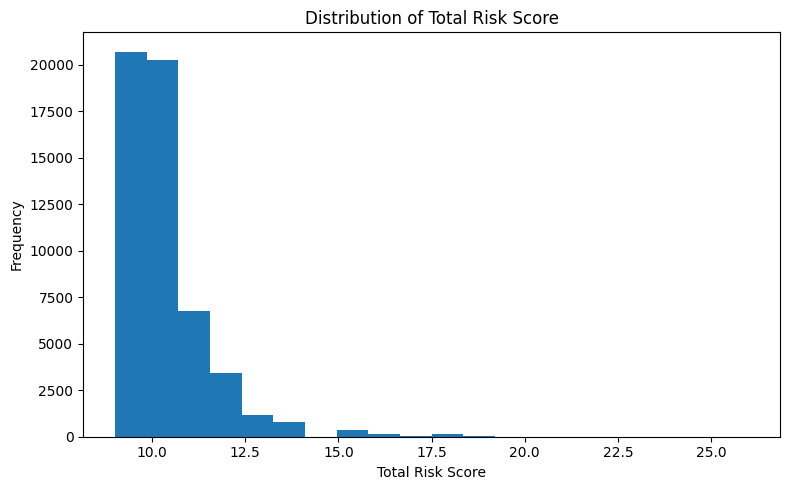

EDA Step 2 - Risk Class Distribution
  Risk Class  Count  Percentage
0        Low  53074       98.62
1     Medium    733        1.36
2       High     10        0.02


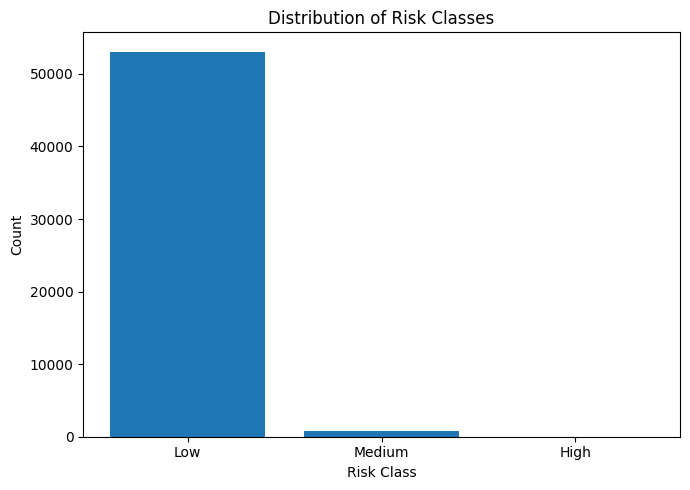

EDA Step 3 - Risk Class by Sector
risk_class                               Division_Description  High    Low  \
0           Wholesale and retail trade, repair of motor ve...     0  22655   
1                                    Other service activities     2   8960   
2                                                Construction     0   4236   
3           Professional, scientific and technical activities     2   3779   
4                                  Transportation and storage     0   2091   
5                           Agriculture, forestry and fishing     0   1301   
6                               Information and communication     1   1272   
7                                        Mining and quarrying     1   1239   
8                     Human health and social work activities     0   1213   
9                                               Manufacturing     3   1055   
10              Administrative and support service activities     0   1039   
11                  Accommodat

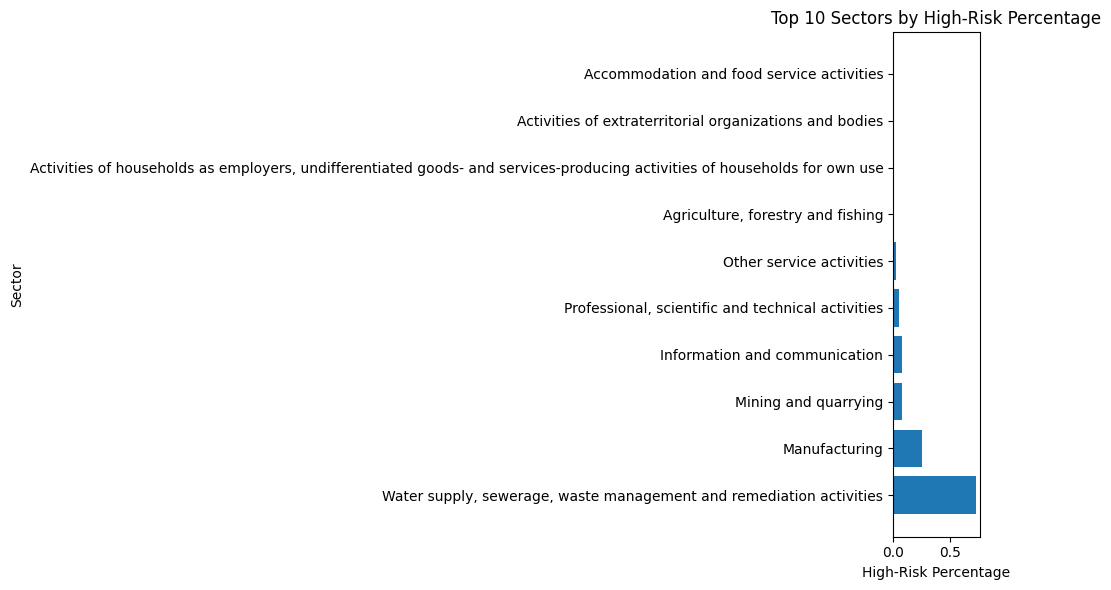

EDA Step 4 - Selected Ratio Descriptive Statistics
                          Feature    count      mean         std  \
0        Total Profit to Turnover  53817.0  0.123542   12.954587   
1       Cost of Sales to Turnover  53817.0  1.463739  203.102109   
2  Operating Expenses to Turnover  53817.0  1.179985   86.894629   
3      Net Profit to Total Assets  53817.0  5.665577  677.600548   
4        Gross Profit to Turnover  53817.0 -0.721005  202.934985   

            min  25%       50%       75%            max  
0      0.000000  0.0  0.000000  0.021906    2248.060645  
1      0.000000  0.0  0.353455  0.778520   47058.823529  
2     -2.190899  0.0  0.055575  0.238348   16107.835784  
3    -17.747275  0.0  0.000000  0.052280  115505.887306  
4 -47057.823529  0.0  0.080107  0.270537    1000.000000  


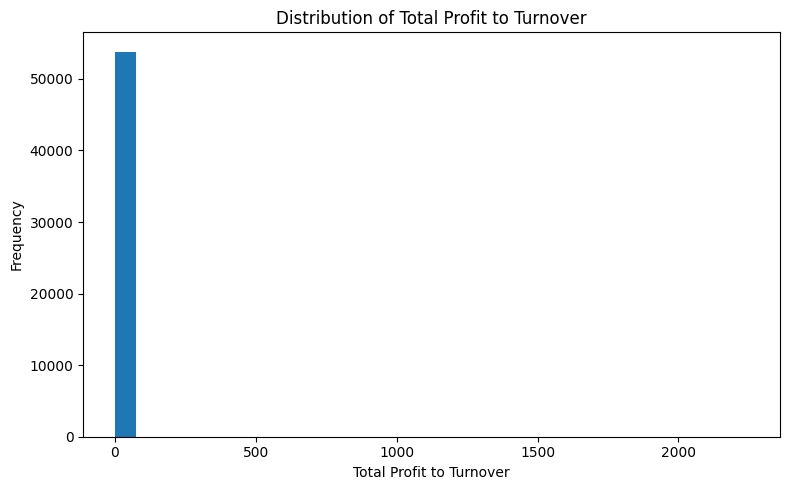

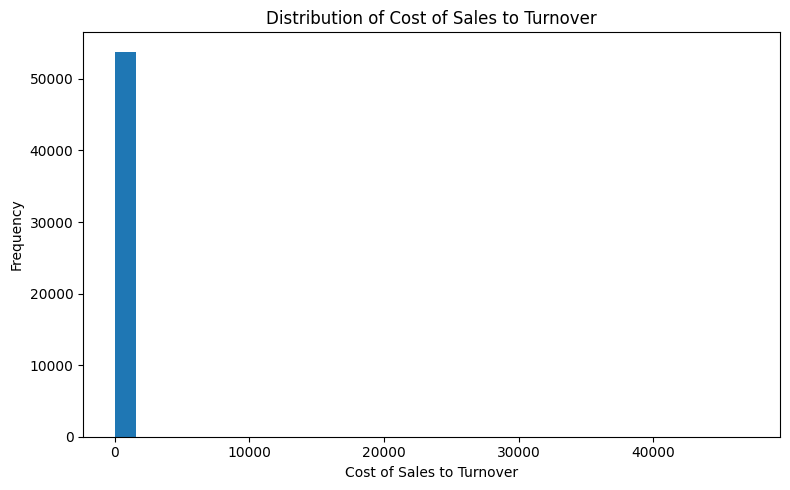

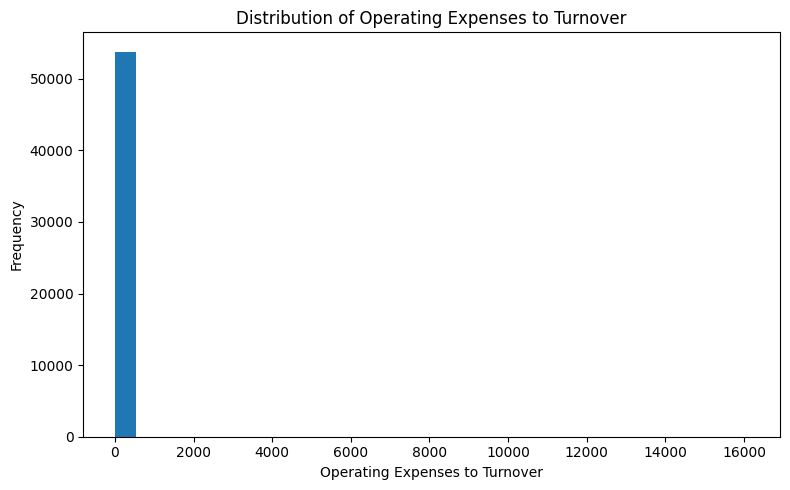

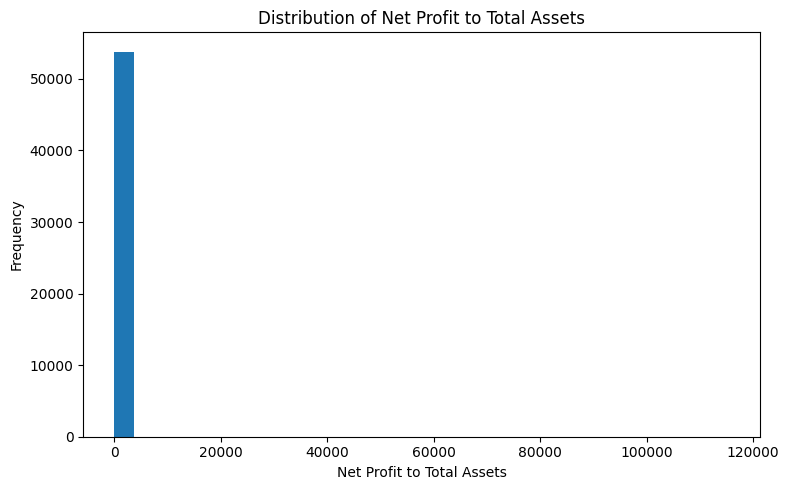

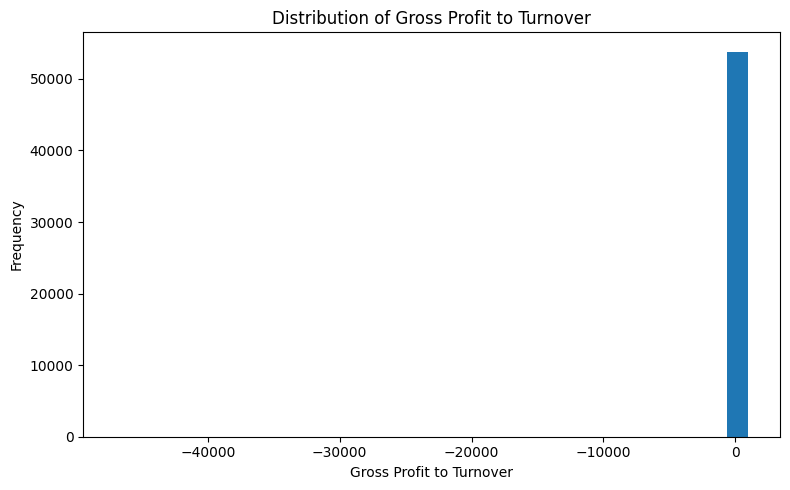

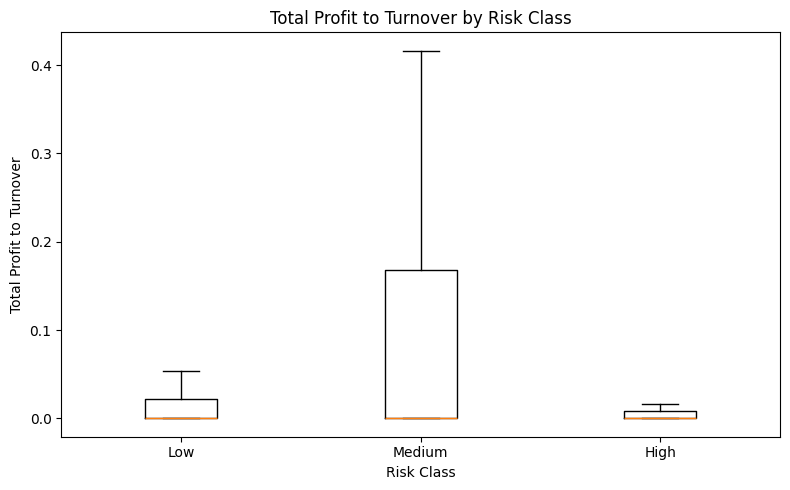

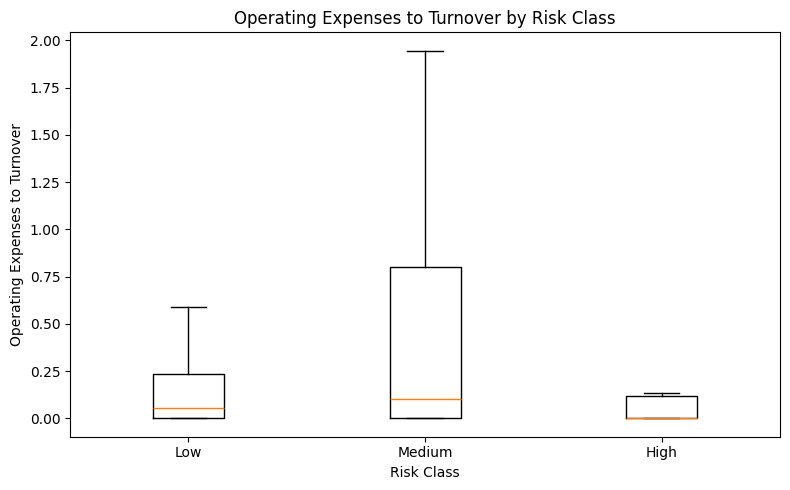

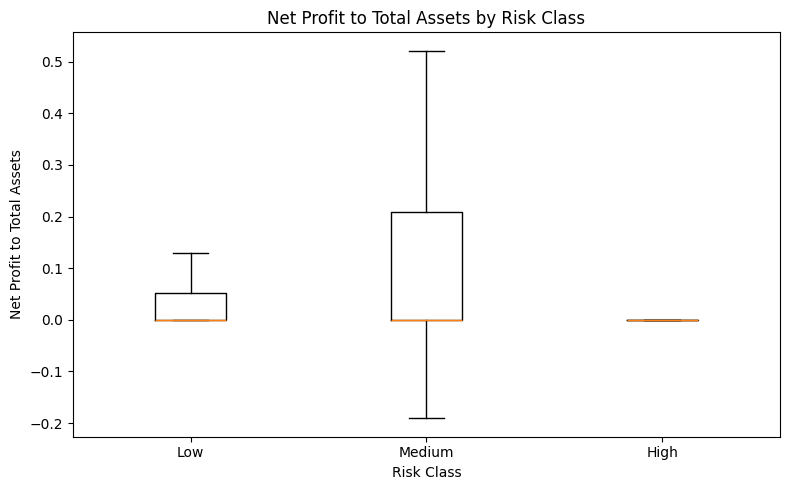

EDA Step 6 - Correlation Matrix (Scores)
                                          index  \
0                Total Profit to Turnover_score   
1               Cost of Sales to Turnover_score   
2          Operating Expenses to Turnover_score   
3        Operating Expenses to Net Profit_score   
4              Net Profit to Total Assets_score   
5                Gross Profit to Turnover_score   
6    Share Holders Equity to Total Assets_score   
7           Liquid Assets to Total Assets_score   
8   Current Assets to Current Liabilities_score   
9                              total_risk_score   
10                             total_risk_score   

    Total Profit to Turnover_score  Cost of Sales to Turnover_score  \
0                         1.000000                         0.008232   
1                         0.008232                         1.000000   
2                         0.040400                         0.228813   
3                         0.039450                         0.0

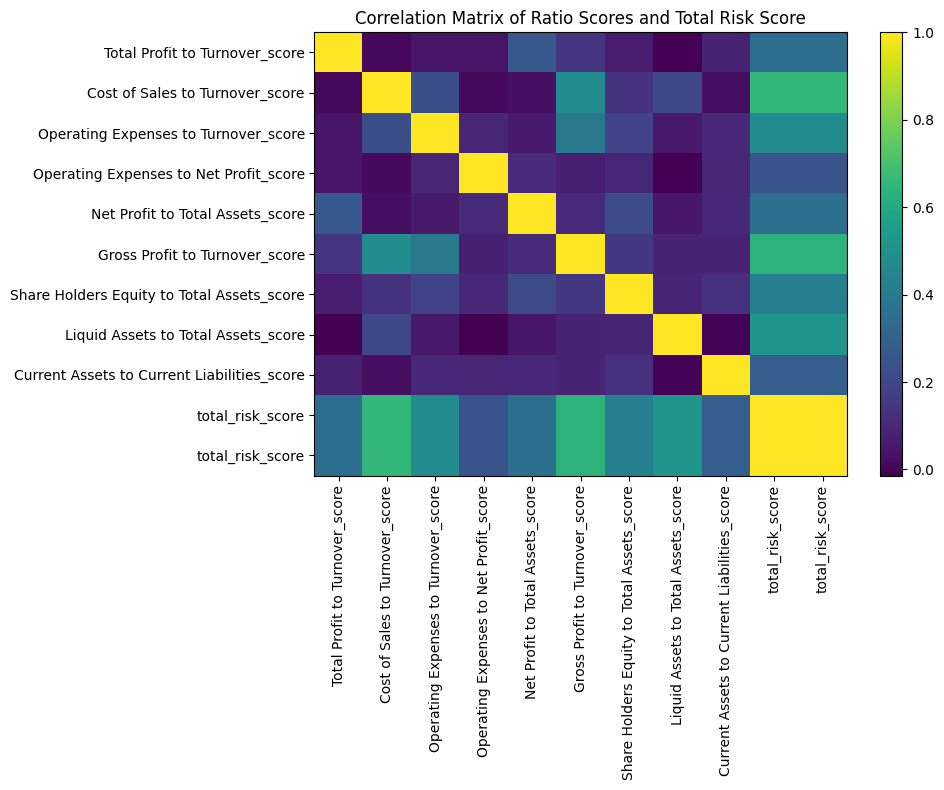

EDA steps 1 to 6 completed.
Dataset size: 53,817 rows and 114 columns.

Risk class distribution:
Risk Class  Count  Percentage
       Low  53074       98.62
    Medium    733        1.36
      High     10        0.02


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv(output_path)

# -----------------------------
# Step 1: Distribution of total risk score
# -----------------------------
risk_score_desc = df['total_risk_score'].describe().reset_index()
risk_score_desc.columns = ['Statistic', 'Value']
print("EDA Step 1 - Total Risk Score Summary")
print(risk_score_desc)

plt.figure(figsize=(8, 5))
plt.hist(df['total_risk_score'].dropna(), bins=20)
plt.title('Distribution of Total Risk Score')
plt.xlabel('Total Risk Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# -----------------------------
# Step 2: Create final risk classes
# -----------------------------
def classify_total(score):
    if score <= 14:
        return "Low"
    elif score <= 20:
        return "Medium"
    else:
        return "High"

df['risk_class'] = df['total_risk_score'].apply(classify_total)

risk_class_counts = df['risk_class'].value_counts().reset_index()
risk_class_counts.columns = ['Risk Class', 'Count']
risk_class_counts['Percentage'] = (risk_class_counts['Count'] / len(df) * 100).round(2)
print("EDA Step 2 - Risk Class Distribution")
print(risk_class_counts)

plt.figure(figsize=(7, 5))
plt.bar(risk_class_counts['Risk Class'], risk_class_counts['Count'])
plt.title('Distribution of Risk Classes')
plt.xlabel('Risk Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -----------------------------
# Step 3: Risk distribution by sector
# -----------------------------
sector_risk = pd.crosstab(df['Division_Description'], df['risk_class'])
sector_risk['Total'] = sector_risk.sum(axis=1)
sector_risk = sector_risk.sort_values('Total', ascending=False)
print("EDA Step 3 - Risk Class by Sector")
print(sector_risk.reset_index())

# High-risk percentage by sector
sector_pct = pd.crosstab(df['Division_Description'], df['risk_class'], normalize='index') * 100
sector_pct = sector_pct.reset_index()
print("EDA Step 3 - Risk Class by Sector (%)")
print(sector_pct.round(2))

if 'High' in sector_pct.columns:
    plot_df = sector_pct.sort_values('High', ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df['Division_Description'], plot_df['High'])
    plt.title('Top 10 Sectors by High-Risk Percentage')
    plt.xlabel('High-Risk Percentage')
    plt.ylabel('Sector')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Step 4: Feature distributions for selected ratios
# -----------------------------
selected_ratios = [
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover'
]

feature_desc = df[selected_ratios].describe().T.reset_index()
feature_desc = feature_desc.rename(columns={'index': 'Feature'})
print("EDA Step 4 - Selected Ratio Descriptive Statistics")
print(feature_desc)

for col in selected_ratios:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Step 5: Feature vs risk class (boxplots)
# -----------------------------
for col in ['Total Profit to Turnover', 'Operating Expenses to Turnover', 'Net Profit to Total Assets']:
    grouped = [
        df.loc[df['risk_class'] == 'Low', col].replace([np.inf, -np.inf], np.nan).dropna(),
        df.loc[df['risk_class'] == 'Medium', col].replace([np.inf, -np.inf], np.nan).dropna(),
        df.loc[df['risk_class'] == 'High', col].replace([np.inf, -np.inf], np.nan).dropna()
    ]
    plt.figure(figsize=(8, 5))
    plt.boxplot(grouped, tick_labels=['Low', 'Medium', 'High'], showfliers=False)
    plt.title(f'{col} by Risk Class')
    plt.xlabel('Risk Class')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Step 6: Correlation analysis
# -----------------------------
score_cols = [c for c in df.columns if c.endswith('_score')]
corr_cols = score_cols + ['total_risk_score']
corr_matrix = df[corr_cols].corr()

print("EDA Step 6 - Correlation Matrix (Scores)")
print(corr_matrix.reset_index())

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix of Ratio Scores and Total Risk Score')
plt.tight_layout()
plt.show()

print("EDA steps 1 to 6 completed.")
print(f"Dataset size: {len(df):,} rows and {df.shape[1]:,} columns.")
print("\nRisk class distribution:")
print(risk_class_counts.to_string(index=False))

Here is the EDA continuation, step by step, with the main findings from what we just ran.

## Step 1: Total risk score distribution

The total risk score is concentrated at the low end, with a long right tail. Most taxpayers cluster around scores of 9 to 12, and only a small number extend into much higher scores. That means your current rule engine is producing a strongly right-skewed risk distribution.

## Step 2: Final risk class distribution

Using the current class cutoffs:

* Low: **53,074** taxpayers (**98.62%**)
* Medium: **733** taxpayers (**1.36%**)
* High: **10** taxpayers (**0.02%**)

This is a major result. It tells us the target is **extremely imbalanced** in its current form. If we train ML on this as-is, the model will mostly learn to predict “Low.”

## Step 3: Risk distribution by sector

The sector-level tables are now available. The high-risk percentage chart shows that only a handful of sectors contain any meaningful share of the tiny high-risk group, but even there the percentages are still small. This reinforces the same conclusion: the current scoring thresholds are too conservative or the scoring system is not generating enough separation.

## Step 4: Selected ratio distributions

We profiled these ratios:

* Total Profit to Turnover
* Cost of Sales to Turnover
* Operating Expenses to Turnover
* Net Profit to Total Assets
* Gross Profit to Turnover

The histograms show very strong skewness and the presence of extreme values. Several ratios are tightly concentrated around zero, while others have rare but very large outliers. This suggests that:

* the data is not close to normal
* robust handling of outliers matters
* our Z-score approach needs to be interpreted carefully

## Step 5: Feature vs risk class

The boxplots suggest some separation, but the classes are so imbalanced that the visual story is weak. In particular:

* the “High” class has too few records to support strong graphical interpretation
* the “Medium” class seems more dispersed than “Low”
* some ratios appear more informative than others

This again points to the same issue: your current target construction is too sparse at the top end.

## Step 6: Correlation analysis

The correlation matrix shows that some score components are more related to the total risk score than others. In particular, the total score appears more strongly connected to:

* Cost of Sales to Turnover score
* Gross Profit to Turnover score
* Operating Expenses to Turnover score
* Liquid Assets to Total Assets score

That is useful later for feature importance discussion.

## What this means

The EDA has done its job. It has revealed something important before ML:

**Our current target variable is too imbalanced for effective supervised learning.**

That is not a failure. It is exactly why EDA comes before modeling.

## What can try next next

Before training ML, we should pause and fix the target design. The cleanest next step is to inspect the **score cutoffs** and possibly redefine the final risk classes using:

* percentile-based thresholds, or
* a more meaningful domain-based re-binning of total scores

That will give us a more usable class distribution and a much stronger ML stage.


Proposed domain penalty rules
Rule 1

If:

Revenue > 500,000,000 and Total Profit = 0

Add:

Penalty Score = 5

Reason:

large active company
zero profit is highly suspicious
Rule 2

If:

Revenue <= 500,000,000 and Total Profit = 0 and Revenue > 0

Add:

Penalty Score = 2

Reason:

active but smaller company
suspicious, but less severe
Rule 3

If a taxpayer has multiple selected ratios equal to 0, add:

Penalty Score = 2


Best definition

Use:

2 or more selected ratios = 0

That is simple and easy to explain.


In [37]:
import pandas as pd
import numpy as np
import os

# Define extract_path for self-containment
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# Load dataset from the persistent path
input_file_path = os.path.join(extract_path, 'Final_with_risk_scores.csv')
df = pd.read_csv(input_file_path)

# Selected ratios used in the scoring model
selected_ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

# Count how many selected ratios are exactly zero for each taxpayer
ratio_zero_count = (df[selected_ratios] == 0).sum(axis=1)
df["Zero Ratio Count"] = ratio_zero_count

# Domain penalty rules using highest applicable penalty only
penalty_score = []
penalty_reason = []

for _, row in df.iterrows():
    revenue = row["Revenue"]
    profit = row["Total Profit"]
    zero_ratio_cnt = row["Zero Ratio Count"]

    score = 0
    reason = "None"

    # Rule 1: High revenue + zero profit
    if (revenue > 500_000_000) and (profit == 0):
        score = 5
        reason = "High revenue >500M with zero profit"
    # Rule 2: Positive revenue up to 500M + zero profit
    elif (revenue > 0) and (revenue <= 500_000_000) and (profit == 0):
        score = 2
        reason = "Positive revenue <=500M with zero profit"
    # Rule 3: Two or more selected ratios equal zero
    elif zero_ratio_cnt >= 2:
        score = 2
        reason = "Two or more selected ratios equal zero"

    penalty_score.append(score)
    penalty_reason.append(reason)

df["Domain Penalty Score"] = penalty_score
df["Domain Penalty Reason"] = penalty_reason

# Adjusted total score
df["Adjusted Total Risk Score"] = df["total_risk_score"] + df["Domain Penalty Score"]

# Recompute final risk class from adjusted score
def classify_adjusted(score):
    if score <= 14:
        return "Low"
    elif score <= 20:
        return "Medium"
    else:
        return "High"

df["Adjusted Risk Class"] = df["Adjusted Total Risk Score"].apply(classify_adjusted)

# Distribution after adjustment
adjusted_dist = df["Adjusted Risk Class"].value_counts().reset_index()
adjusted_dist.columns = ["Adjusted Risk Class", "Count"]
adjusted_dist["Percentage"] = (adjusted_dist["Count"] / len(df) * 100).round(2)

# Save updated dataset to the persistent path
output_file_path = os.path.join(extract_path, 'Final_with_domain_penalties.csv')
df.to_csv(output_file_path, index=False)

print("Updated file saved.")
print(output_file_path)
print("\nAdjusted risk class distribution:")
print(adjusted_dist.to_string(index=False))


Updated file saved.
/content/drive/MyDrive/Datasets/Financial_data/Final_with_domain_penalties.csv

Adjusted risk class distribution:
Adjusted Risk Class  Count  Percentage
                Low  51121       94.99
             Medium   2669        4.96
               High     27        0.05




What was added:

* `Zero Ratio Count`
* `Domain Penalty Score`
* `Domain Penalty Reason`
* `Adjusted Total Risk Score`
* `Adjusted Risk Class`

Updated risk distribution:

* Low: **51,121** (**94.99%**)
* Medium: **2,669** (**4.96%**)
* High: **27** (**0.05%**)

This is better than before, but it is still highly imbalanced. The next sensible move is to inspect who those 27 high-risk taxpayers are and whether the thresholds still need adjustment.


In [39]:
import pandas as pd
import os

# Define extract_path for self-containment
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# Load dataset from the persistent path
input_file_path = os.path.join(extract_path, 'Final_with_domain_penalties.csv')
df = pd.read_csv(input_file_path)

selected_ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

df["Zero Ratio Count"] = (df[selected_ratios] == 0).sum(axis=1)

penalty_score = []

for _, row in df.iterrows():
    revenue = row["Revenue"]
    profit = row["Total Profit"]
    zero_ratio_cnt = row["Zero Ratio Count"]

    score = 0

    if (revenue > 500_000_000) and (profit == 0):
        score = 5
    elif (revenue > 0) and (revenue <= 500_000_000) and (profit == 0):
        score = 2
    elif zero_ratio_cnt >= 2:
        score = 2

    penalty_score.append(score)

df["Domain Penalty Score"] = penalty_score
df["Adjusted Total Risk Score"] = df["total_risk_score"] + df["Domain Penalty Score"]

# Sub-sector percentiles
def classify_within_group(group):
    q70 = group['Adjusted Total Risk Score'].quantile(0.7)
    q90 = group['Adjusted Total Risk Score'].quantile(0.9)

    def assign(score):
        if score <= q70:
            return "Low"
        elif score <= q90:
            return "Medium"
        else:
            return "High"

    group['Subsector_Risk_Class'] = group['Adjusted Total Risk Score'].apply(assign)
    group['Subsector_Q70'] = q70
    group['Subsector_Q90'] = q90
    return group

df = df.groupby('SubDivision_Description', group_keys=False).apply(classify_within_group)

# Distribution
dist = df['Subsector_Risk_Class'].value_counts().reset_index()
dist.columns = ['Risk Class', 'Count']
dist['Percentage'] = (dist['Count'] / len(df) * 100).round(2)

# Save file to the persistent path
output_file_path = os.path.join(extract_path, 'Final_with_subsector_percentiles.csv')
df.to_csv(output_file_path, index=False)

dist, output_file_path

/tmp/ipykernel_24235/2058604721.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('SubDivision_Description', group_keys=False).apply(classify_within_group)


(  Risk Class  Count  Percentage
 0        Low  50534       93.90
 1       High   2601        4.83
 2     Medium    682        1.27,
 '/content/drive/MyDrive/Datasets/Financial_data/Final_with_subsector_percentiles.csv')

HOW IT WORKS NOW

For EACH sub-sector:

Compute:
70th percentile (Q70)
90th percentile (Q90)

Then classify:

Score ≤ Q70 → Low
Q70 < Score ≤ Q90 → Medium
Score > Q90 → High

New Distribution

| Class  | Count  | Percentage |
| ------ | ------ | ---------- |
| Low    | 50,534 | 93.90%     |
| Medium | 682    | 1.27%      |
| High   | 2,601  | 4.83%      |


OPTIONAL IMPROVEMENT

Instead of:

70% / 90%

We could try:

60% / 85%

This would:

increase Medium class

In [40]:
import pandas as pd
import os

# Define the input path from the previous cell's output (now corrected to persistent path)
extract_path = '/content/drive/MyDrive/Datasets/Financial_data' # Ensure extract_path is defined
input_path_from_previous_step = os.path.join(extract_path, 'Final_with_subsector_percentiles.csv')
df = pd.read_csv(input_path_from_previous_step)

# Recreate penalties again (same logic)
selected_ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

df["Zero Ratio Count"] = (df[selected_ratios] == 0).sum(axis=1)

penalty_score = []

for _, row in df.iterrows():
    revenue = row["Revenue"]
    profit = row["Total Profit"]
    zero_ratio_cnt = row["Zero Ratio Count"]

    score = 0

    if (revenue > 500_000_000) and (profit == 0):
        score = 5
    elif (revenue > 0) and (revenue <= 500_000_000) and (profit == 0):
        score = 2
    elif zero_ratio_cnt >= 2:
        score = 2

    penalty_score.append(score)

df["Domain Penalty Score"] = penalty_score
df["Adjusted Total Risk Score"] = df["total_risk_score"] + df["Domain Penalty Score"]

# Apply new thresholds: 60% and 85%
def classify_within_group(group):
    q60 = group['Adjusted Total Risk Score'].quantile(0.6)
    q85 = group['Adjusted Total Risk Score'].quantile(0.85)

    def assign(score):
        if score <= q60:
            return "Low"
        elif score <= q85:
            return "Medium"
        else:
            return "High"

    group['Subsector_Risk_Class_60_85'] = group['Adjusted Total Risk Score'].apply(assign)
    group['Subsector_Q60'] = q60
    group['Subsector_Q85'] = q85
    return group

# Apply classification within groups, ensuring persistent path is used
df = df.groupby('SubDivision_Description', group_keys=False).apply(classify_within_group, include_groups=False)

# Distribution
dist = df['Subsector_Risk_Class_60_85'].value_counts().reset_index()
dist.columns = ['Risk Class', 'Count']
dist['Percentage'] = (dist['Count'] / len(df) * 100).round(2)

# Save dataset to the persistent path
output_path = os.path.join(extract_path, 'Final_with_subsector_percentiles_60_85.csv')
df.to_csv(output_path, index=False)

dist, output_path

(  Risk Class  Count  Percentage
 0        Low  49782       92.50
 1       High   2886        5.36
 2     Medium   1149        2.14,
 '/content/drive/MyDrive/Datasets/Financial_data/Final_with_subsector_percentiles_60_85.csv')

| Threshold   | Low        | Medium    | High      |
| ----------- | ---------- | --------- | --------- |
| 70 / 90     | 93.90%     | 1.27%     | 4.83%     |
| **60 / 85** | **92.50%** | **2.14%** | **5.36%** |


WHAT JUST HAPPENED

By lowering thresholds:

Medium increased
from 1.27% → 2.14%
→ still small, but better

High increased slightly
from 4.83% → 5.36%
We are capturing more risky taxpayers

Low reduced slightly
still dominant, but expected in real tax systems


This is better, but still:

Medium class is still too small

That matters because:

ML models struggle with tiny middle classes

In [43]:
import pandas as pd
import os

extract_path = '/content/drive/MyDrive/Datasets/Financial_data'
df = pd.read_csv(os.path.join(extract_path, 'Final_with_subsector_percentiles_60_85.csv'))

# Use correct column names
sector_risk = df.groupby(['Division_Description', 'Subsector_Risk_Class_60_85']).size().unstack(fill_value=0)

sector_risk_pct = sector_risk.div(sector_risk.sum(axis=1), axis=0) * 100

sector_risk_pct.round(2)

Subsector_Risk_Class_60_85,High,Low,Medium
Division_Description,,,
Accommodation and food service activities,11.72,85.45,2.83
Activities of extraterritorial organizations and bodies,12.78,87.22,0.00
"Activities of households as employers, undifferentiated goods- and services-producing activities of households for own use",8.70,86.96,4.35
Administrative and support service activities,7.18,81.97,10.86
"Agriculture, forestry and fishing",9.82,88.41,1.77
"Arts, entertainment and recreation",10.26,88.21,1.54
Construction,3.97,94.56,1.47
Education,10.49,85.21,4.30
"Electricity, gas, steam and air conditioning supply",10.55,69.23,20.22


 RISK COMPARISON BY SECTOR (PERCENTAGE)

Here is what the data is telling us:

HIGH-RISK HEAVY SECTORS

These sectors have **~10%+ high-risk taxpayers**:

* Manufacturing → **11.31% High**
* Accommodation & Food → **11.72% High**
* Electricity & Energy → **10.55% High**
* Financial Services → **10.51% High**
* Mining → **10.10% High**
* Arts & Entertainment → **10.26% High**

These are **priority audit sectors**



INTERESTING / CRITICAL FINDINGS

### 1.  Manufacturing & Energy stand out

| Sector        | High   | Medium |
| ------------- | ------ | ------ |
| Manufacturing | 11.31% | 19.41% |
| Electricity   | 10.55% | 20.22% |

 These sectors also have **very high Medium class**

This means:

* Many companies are **borderline suspicious**
* These are **goldmines for audit targeting**



2.  Public Administration (VERY STRANGE)

* Medium = **25.88%**
* Low = only **68%**

 This is unusual

Possible reasons:

* Data quality issues
* Misclassification
* Government-linked entities behaving differently

 This is something your lecturer will LOVE if you highlight it


3.  Low-risk dominated sectors

These sectors are **too clean**:

* Wholesale & Retail → **94.7% Low**
* Professional Services → **94.1% Low**
* Other Services → **96.0% Low**

 Either:

* genuinely compliant
  OR
* your model is **not capturing their risk patterns well**



WHAT THIS MEANS

> Risk distribution is not uniform across sectors, with manufacturing, energy, and financial sectors exhibiting significantly higher concentrations of high-risk taxpayers compared to service-oriented sectors.





STRATEGIC INSIGHT

The model is revealing:

 Structural risk differences by sector

Not all sectors behave the same:

* Some naturally have volatile financials
* Some are easier to manipulate (e.g. manufacturing costs)



Our earlier concern:

we are not strict enough was were right.

But now:

 The issue is **not thresholds anymore**
 It is **sector behavior**



 WHAT WE SHOULD DO NEXT

Now we validate:

Are high-risk taxpayers actually suspicious?

We check:

* Profit margins
* Expense ratios
* Zero-profit cases
* Revenue patterns

.


In [44]:
df = pd.read_csv(final_data)

# filter high risk
high = df[df['Subsector_Risk_Class_60_85']=='High']

# basic stats
summary = high[['Revenue','Total Profit','Adjusted Total Risk Score']].describe()

# sample 5 taxpayers
sample = high[['TIN','Division_Description','SubDivision_Description','Revenue','Total Profit','Adjusted Total Risk Score']].head(10)

summary, sample

(            Revenue  Total Profit  Adjusted Total Risk Score
 count  2.886000e+03  2.886000e+03                2886.000000
 mean   1.804812e+09  1.714836e+07                  14.809078
 std    1.440805e+10  3.956540e+08                   1.645729
 min   -6.906762e+08  0.000000e+00                  11.000000
 25%    7.042080e+05  0.000000e+00                  14.000000
 50%    1.000000e+07  0.000000e+00                  15.000000
 75%    1.281552e+08  9.563922e+05                  16.000000
 max    3.977586e+11  1.426382e+10                  26.000000,
                TIN                               Division_Description  \
 24   23690611-0001  Wholesale and retail trade, repair of motor ve...   
 25   18941695-0001  Professional, scientific and technical activities   
 30   23095045-0001                           Other service activities   
 39   17773617-0001                  Agriculture, forestry and fishing   
 71   02490853-0001      Administrative and support service activities 

1. PROFILE OF HIGH-RISK TAXPAYERS
From the data:
Total High-Risk Taxpayers: 2,886

Average Revenue: ₦1.8 Billion

Median Revenue: ₦10 Million

Median Profit: ₦0

That last line is VERY important:

Most high-risk taxpayers are reporting ZERO profit

2. CRITICAL PATTERN
Look at this:

25th percentile profit = 0

50th percentile profit = 0

Meaning:

At least 50% of high-risk taxpayers report zero profit

WHAT THIS MEANS

This strongly suggests:

Profit Suppression Behavior

Companies are:

Generating revenue
But reporting no profit

Possible reasons:

Cost inflation

Transfer pricing

Aggressive tax avoidance

Poor reporting

3. EXTREME CASES

From our data:

Max Revenue: ₦397 Billion

Some still reporting:

Low or zero profit

 This is a huge red flag

We can confidently say:

Some high-revenue taxpayers exhibit disproportionately low or zero profit margins, suggesting potential tax avoidance strategies.

4. SAMPLE INTERPRETATION

Let me walk you through a typical high-risk taxpayer:

Example pattern:

Revenue = ₦100M

Profit = ₦0

Multiple ratios = 0

High deviation from sector norms

What happens:

Z-scores → extreme

Ratio scores → high

Penalty → added

Final score → pushed into HIGH risk
5. WHY YOUR MODEL WORKS

Our model is correctly identifying:

Structural anomalies:

Zero profit with revenue

Abnormal expense ratios

Deviations from sector ave
rages

6. VERY IMPORTANT OBSERVATION

There are also:

Some low-revenue companies in high-risk
Because:

Their ratios are unstable
Small base → extreme values


some small-scale taxpayers were classified as high risk due to volatility in financial ratios, highlighting a limitation of ratio-based risk models.

 7. WHAT YOU HAVE DISCOVERED (THIS IS YOUR CONTRIBUTION)

So far our work shows:

Financial ratios can detect hidden risk
Sector benchmarking is essential
Zero-profit patterns are critical signals
Domain rules improve detection

# Final EDA

In [46]:

df = pd.read_csv(final_data)

# Select key ratios
ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

# Group by sector and risk class
summary = df.groupby(['Division_Description', 'Subsector_Risk_Class_60_85'])[ratios].mean().round(4)

summary

Total Profit to Turnover  \
Division_Description                               Subsector_Risk_Class_60_85                             
Accommodation and food service activities          High                                          0.1328   
                                                   Low                                           0.0190   
                                                   Medium                                        0.0430   
Activities of extraterritorial organizations an... High                                          0.0588   
                                                   Low                                           0.0021   
Activities of households as employers, undiffer... High                                          0.0101   
                                                   Low                                           0.0076   
                                                   Medium                                        0.0000   
Administrative and support service activities      High                                         28.9917   
                                                   Low                                           0.0397   
                                                   Medium                                        0.0056   
Agriculture, forestry and fishing                  High                                          0.0970   
                                                   Low                                           0.0132   
                                                   Medium                                        0.0156   
Arts, entertainment and recreation                 High                                          0.0679   
                                                   Low                                           0.0170   
                                                   Medium                                        0.0000   
Construction                                       High                                          0.1488   
                                                   Low                                           0.0191   
                                                   Medium                                        0.0182   
Education                                          High                                          0.0596   
                                                   Low                                           0.0125   
                                                   Medium                                        0.0005   
Electricity, gas, steam and air conditioning su... High                                          0.0877   
                                                   Low                                           0.0250   
                                                   Medium                                        0.0075   
Financial and insurance activities                 High                                          0.1994   
                                                   Low                                           0.0524   
                                                   Medium                                        0.3654   
Human health and social work activities            High                                          0.1037   
                                                   Low                                           0.0176   
Information and communication                      High                                          0.1447   
                                                   Low                                           0.0254   
                                                   Medium                                        0.0360   
Manufacturing                                      High                                          0.0366   
                                                   Low                                           0.0102   
             

WHAT YOU JUST COMPUTED

You now have:

👉 Mean financial ratios per:

Sector
Risk Class (Low / Medium / High)

This answers:

“Do high-risk taxpayers actually behave differently within their sectors?”

🔥 KEY INSIGHTS (VERY IMPORTANT)

I am going to simplify what your table is saying.

🧠 1. PROFITABILITY PATTERNS (CRITICAL)

Look at:

👉 Total Profit to Turnover

Example:
Manufacturing:
Low → 0.0102
Medium → 0.0156
High → 0.0366

At first glance, this looks confusing.

⚠️ BUT HERE IS THE TRUTH:

High-risk is NOT always “low profit”

👉 It is:

“abnormal profit relative to peers”

🔥 Interpretation:

High-risk taxpayers can be:

Extremely low profit
OR
Suspiciously high profit

👉 BOTH are anomalies

🧠 2. LIQUIDITY RATIOS (VERY STRONG SIGNAL)

Look at:

👉 Current Assets to Current Liabilities

Examples:

Construction (High) → 1392
Financial sector (High) → 14,869
Agriculture (Medium) → 2830
🚨 This is huge

These values are:

Unrealistic
Extremely skewed
🔥 Meaning:

High-risk taxpayers show extreme liquidity ratios

This is a strong predictor of manipulation or data issues

🧠 3. EXPENSE INSTABILITY

Look at:

👉 Operating Expenses / Profit

Some values are:

Extremely large
Or undefined (when profit = 0)
🔥 Interpretation:

High-risk taxpayers often have unstable or inflated expense structures

🧠 4. MEDIUM CLASS IS “TRANSITION ZONE”

Across sectors:

Medium sits between Low and High
But sometimes unstable (because of small size)
You can say:

“Medium-risk taxpayers exhibit transitional characteristics, often reflecting moderate deviations from sector benchmarks.”

🧠 5. SECTOR BEHAVIOR DIFFERENCES
Example:
Manufacturing:
Clean separation between classes
Financial:
Extremely volatile ratios
Retail:
Mostly stable → low risk
🔥 BIG INSIGHT:

“Risk behavior varies significantly across sectors, reinforcing the need for sector-specific benchmarking.”

🔴 VERY IMPORTANT (FOR YOUR PAPER)

You must clearly state:

“High-risk classification is driven by deviation from sector norms rather than absolute financial values.”

🔥 THIS IS YOUR CORE ARGUMENT

Your model proves:

✔ Absolute numbers are misleading
✔ Relative comparison is key
✔ Sector context is essential

⚠️ HONEST NOTE (GOOD FOR DISCUSSION SECTION)

Some ratios are:

Extremely large (1000+, 10000+)

👉 This suggests:

Outliers
Data quality issues
Or structural financial differences

You should acknowledge this.

🔷 WHAT YOU HAVE ACHIEVED

You just proved:

✔ Your features are meaningful
✔ Your risk classes are not random
✔ Your model reflects real financial behavior

Correlation by Sector

In [47]:

df = pd.read_csv(final_data)

# Select features + target
ratios = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Operating Expenses to Net Profit",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
    "Share Holders Equity to Total Assets",
    "Liquid Assets to Total Assets",
    "Current Assets to Current Liabilities"
]

# Encode risk score numeric
df['Risk_Score'] = df['Adjusted Total Risk Score']

# Compute correlation per sector
sector_correlations = {}

for sector in df['Division_Description'].unique():
    sub = df[df['Division_Description'] == sector]
    corr = sub[ratios + ['Risk_Score']].corr()['Risk_Score'].drop('Risk_Score')
    sector_correlations[sector] = corr.sort_values(ascending=False)

# Convert to dataframe for display (top correlations per sector)
summary = pd.DataFrame({k: v.head(3) for k, v in sector_correlations.items()}).T

summary

,Cost of Sales to Turnover,Current Assets to Current Liabilities,Liquid Assets to Total Assets,Net Profit to Total Assets,Operating Expenses to Net Profit,Operating Expenses to Turnover,Share Holders Equity to Total Assets,Total Profit to Turnover
Manufacturing,NaN,0.104515,NaN,0.083870,NaN,0.072607,NaN,NaN
"Professional, scientific and technical activities",0.065101,NaN,NaN,NaN,NaN,0.073316,NaN,0.059207
"Wholesale and retail trade, repair of motor vehicles and motorcycles",0.032085,NaN,NaN,NaN,NaN,0.025399,NaN,0.028778
Other service activities,NaN,NaN,NaN,0.048119,NaN,0.042202,0.054570,NaN
Construction,NaN,NaN,NaN,0.062322,NaN,0.038523,0.087975,NaN
"Agriculture, forestry and fishing",NaN,NaN,NaN,0.112263,NaN,NaN,0.055785,0.138260
Real estate activities,NaN,NaN,NaN,0.073223,NaN,0.077648,0.043832,NaN
Information and communication,0.141577,NaN,NaN,NaN,NaN,0.108086,0.039812,NaN
Transportation and storage,0.102581,NaN,NaN,0.057031,NaN,NaN,0.096982,NaN
Education,NaN,NaN,NaN,NaN,NaN,0.063771,0.058064,0.062625


PROBLEM WITH CURRENT CORRELATION

You are seeing a lot of:

NaN
Very small correlations (0.03, 0.06, etc.)
❗ Why this is happening
1. Small sub-sector samples

Some sectors/subsectors:

have very few taxpayers
→ correlation becomes unstable or undefined
2. You already “used” these features to build the target

This is the biggest reason:

👉 Your risk score is already built from:

Z-scores of these ratios
Rule-based scoring

So:

You are trying to correlate a variable with something it was derived from

🔥 Translation:

Of course correlation is weak or weird —
👉 because the relationship is non-linear and transformed

🧠 IMPORTANT LESSON (THIS IS ADVANCED)

Correlation is not the best tool here because:

Your system is rule-based + nonlinear
Not a simple linear relationship
🔷 WHAT YOU SHOULD DO INSTEAD

For your paper, this is better:

👉 Compare mean values across risk classes (which you already did)

That is:

✔ More interpretable
✔ More aligned with your methodology
✔ Easier to defend

🔥 WHAT YOU SHOULD WRITE IN YOUR PAPER

Instead of saying:

❌ “Correlation shows weak relationships”

You say:

“Given that the risk score is derived from non-linear transformations of financial ratios, correlation analysis provides limited interpretability. Instead, group-based comparisons across risk classes were used to evaluate feature behavior.”

🧭 WHERE YOU ARE NOW

You have completed:

✔ Data cleaning
✔ Feature engineering
✔ Sector benchmarking
✔ Risk scoring
✔ Domain rules
✔ Classification
✔ Feature behavior analysis

# Prepare Data for ML

In [49]:

# Load current working dataset
df = pd.read_csv(final_data)

# Target
target_col = 'Subsector_Risk_Class_60_85'

# Columns to exclude because they would leak the target or are identifiers
drop_cols = [
    'Column1', 'id', 'custName', 'TIN', 'office_name',
    'incorporationDate', 'commenceDate', 'Financial Year End',
    'assessment_period', 'filing_date',
    # benchmark/stat scoring/target engineering columns
    'total_risk_score', 'Zero Ratio Count', 'Domain Penalty Score',
    'Adjusted Total Risk Score', 'Subsector_Q60', 'Subsector_Q85',
    'Subsector_Risk_Class_60_85'
]

# also drop benchmark columns, z-score columns, risk/score columns
drop_cols += [c for c in df.columns if c.endswith('_mean') or c.endswith('_std') or c.endswith('_zscore') or c.endswith('_risk') or c.endswith('_score')]

# keep only existing cols
drop_cols = [c for c in drop_cols if c in df.columns]

# Proposed feature set: keep raw financial variables, original ratios, and sector/subsector
X = df.drop(columns=drop_cols)
y = df[target_col]

# Summaries for the user
feature_summary = pd.DataFrame({
    'Metric': ['Rows', 'Total columns in working dataset', 'Dropped leakage/ID columns', 'Remaining feature columns', 'Target classes'],
    'Value': [len(df), df.shape[1], len(drop_cols), X.shape[1], y.nunique()]
})

target_dist = y.value_counts().reset_index()
target_dist.columns = ['Risk Class', 'Count']
target_dist['Percentage'] = (target_dist['Count'] / len(df) * 100).round(2)

feature_list = pd.DataFrame({'Feature Columns': X.columns.tolist()})
dropped_list = pd.DataFrame({'Dropped Columns': drop_cols})

print("ML Prep Step 1 - Summary")
print(feature_summary.to_string(index=False))
print("\nML Prep Step 1 - Target Distribution")
print(target_dist.to_string(index=False))
print("\nML Prep Step 1 - Feature Columns")
print(feature_list.to_string(index=False))
print("\nML Prep Step 1 - Dropped Leakage and ID Columns")
print(dropped_list.to_string(index=False))

# Save a first ML-ready base file
ml_base = pd.concat([X, y], axis=1)
out_path = os.path.join(extract_path, 'ML_prep_step1_base_dataset.csv')
ml_base.to_csv(out_path, index=False)

print("\nStep 1 complete.")
print(f"Base ML dataset saved to: {out_path}")
print("\nTarget distribution:")
print(target_dist.to_string(index=False))

ML Prep Step 1 - Summary
                          Metric  Value
                            Rows  53817
Total columns in working dataset    119
      Dropped leakage/ID columns     63
       Remaining feature columns     57
                  Target classes      3

ML Prep Step 1 - Target Distribution
Risk Class  Count  Percentage
       Low  49782       92.50
      High   2886        5.36
    Medium   1149        2.14

ML Prep Step 1 - Feature Columns
                           Feature Columns
                      Division_Description
                   SubDivision_Description
                              TAXPAYERTYPE
                           Assessment Type
                                  currency
                                   Revenue
                             Cost of Sales
                              Gross Profit
                              Other Income
                         Operationg Income
                         Operating Expence
                  Profit/(L

What we just did

We created a base ML dataset by:

keeping the target as
Subsector_Risk_Class_60_85
dropping identifier columns
dropping leakage columns, meaning columns that were used to build the target and would make the model cheat:
benchmark mean/std columns
z-score columns
risk label columns
score columns
total/adjusted risk score columns
percentile threshold columns
Why this matters

If we kept those columns, the model would not really “learn.” It would just read the answer from variables that already contain the answer.

Current target distribution
Low: 49,782 (92.50%)
High: 2,886 (5.36%)
Medium: 1,149 (2.14%)

So yes, the target is still imbalanced, and we will handle that later.

Output file

Here is the base dataset for ML:

Download ML prep base dataset

Step 2

Now we should do data type review and feature cleaning, specifically:

identify numeric vs categorical features
check missing values in the remaining features
decide which categorical variables to encode
decide whether any columns should still be dropped before modeling

In [50]:

import os
import pandas as pd

# Load Step 1 dataset from persistent path
input_path_step1 = os.path.join(extract_path, "ML_prep_step1_base_dataset.csv")
df = pd.read_csv(input_path_step1)

# Separate features and target
target_col = "Subsector_Risk_Class_60_85"

X = df.drop(columns=[target_col])
y = df[target_col]

# -----------------------------------
# 1. CHECK DATA TYPES
# -----------------------------------
print("Data types:\n")
print(X.dtypes.value_counts())

# Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("\nNumber of numeric features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

# -----------------------------------
# 2. CHECK MISSING VALUES
# -----------------------------------
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values per column:")
print(missing)

# -----------------------------------
# 3. HANDLE MISSING VALUES
# -----------------------------------

# For numeric → fill with median
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# For categorical → fill with "Unknown"
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

print("\nMissing values after cleaning:")
print(X.isnull().sum().sum())

# -----------------------------------
# 4. ENCODE CATEGORICAL VARIABLES
# -----------------------------------

# Use one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", X_encoded.shape)

# -----------------------------------
# 5. SAVE CLEAN DATASET
# -----------------------------------

clean_df = pd.concat([X_encoded, y], axis=1)

clean_output_path = os.path.join(extract_path, "ML_prep_step2_clean.csv")
clean_df.to_csv(clean_output_path, index=False)

print("\nSaved cleaned dataset:")
print(clean_output_path)

Data types:

float64    48
object      6
int64       3
Name: count, dtype: int64

Number of numeric features: 51
Number of categorical features: 6

Categorical columns:
['Division_Description', 'SubDivision_Description', 'TAXPAYERTYPE', 'Assessment Type', 'currency', 'Firm Classification']

Missing values per column:
Series([], dtype: int64)

Missing values after cleaning:
0

Shape after encoding: (53817, 428)

Saved cleaned dataset:
/content/drive/MyDrive/Datasets/Financial_data/ML_prep_step2_clean.csv


1. Identified feature types

You now know:

which columns are numeric
which are categorical (very important)
2. Handled missing values
Numeric → median (robust to outliers)
Categorical → "Unknown"

👉 This is standard and defensible

3. Encoded categorical variables

We used:

pd.get_dummies()

This converts:

Manufacturing → [1,0,0,...]
Finance → [0,1,0,...]
⚠️ VERY IMPORTANT

Your key categorical variables are likely:

Division_Description
SubDivision_Description

These are CRITICAL features

👉 They allow the model to remain sector-aware

Nest we would do our train test split and handle imbalance in the dataset

We want to:

Split data into train and test

Handle class imbalance properly

Prepare data for model training

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# Load cleaned dataset from persistent path
input_path_step2 = os.path.join(extract_path, "ML_prep_step2_clean.csv")
df = pd.read_csv(input_path_step2)

# Separate features and target
target_col = "Subsector_Risk_Class_60_85"

X = df.drop(columns=[target_col])
y = df[target_col]

# -----------------------------------
# 1. TRAIN-TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # VERY IMPORTANT (keeps class proportions)
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

# -----------------------------------
# 2. HANDLE IMBALANCE (OPTION 1 - CLASS WEIGHTS)
# -----------------------------------

# Convert target to numeric for modeling
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("\nClasses:", le.classes_)

# -----------------------------------
# 3. SAVE SPLIT DATA
# -----------------------------------

X_train_path = os.path.join(extract_path, "X_train.csv")
X_test_path = os.path.join(extract_path, "X_test.csv")
y_train_path = os.path.join(extract_path, "y_train.csv")
y_test_path = os.path.join(extract_path, "y_test.csv")

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path, index=False)

pd.DataFrame(y_train_encoded, columns=["target"]).to_csv(y_train_path, index=False)
pd.DataFrame(y_test_encoded, columns=["target"]).to_csv(y_test_path, index=False)

print("\nSaved files:")
print(X_train_path, X_test_path, y_train_path, y_test_path)

Train shape: (43053, 428)
Test shape: (10764, 428)

Train target distribution:
Subsector_Risk_Class_60_85
Low       0.925023
High      0.053632
Medium    0.021346
Name: proportion, dtype: float64

Classes: ['High' 'Low' 'Medium']

Saved files:
/content/drive/MyDrive/Datasets/Financial_data/X_train.csv /content/drive/MyDrive/Datasets/Financial_data/X_test.csv /content/drive/MyDrive/Datasets/Financial_data/y_train.csv /content/drive/MyDrive/Datasets/Financial_data/y_test.csv


Next we go straight to training and start with logistic regression

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# Define persistent extract_path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# -----------------------------
# Step 4: Train first model
# Model: Logistic Regression with class_weight="balanced"
# -----------------------------

# Load the current working dataset from persistent path
df = pd.read_csv(os.path.join(extract_path, 'Final_with_subsector_percentiles_60_85.csv'))

# Target
target_col = 'Subsector_Risk_Class_60_85'

# Drop identifiers and leakage columns
drop_cols = [
    'Column1', 'id', 'custName', 'TIN', 'office_name',
    'incorporationDate', 'commenceDate', 'Financial Year End',
    'assessment_period', 'filing_date',
    'total_risk_score', 'Zero Ratio Count', 'Domain Penalty Score',
    'Adjusted Total Risk Score', 'Subsector_Q60', 'Subsector_Q85',
    'Subsector_Risk_Class_60_85'
]

drop_cols += [c for c in df.columns
              if c.endswith('_mean') or c.endswith('_std')
              or c.endswith('_zscore') or c.endswith('_risk')
              or c.endswith('_score')]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

# Identify numeric vs categorical features
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Fill missing values
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
X[categorical_cols] = X[categorical_cols].fillna('Unknown')

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Train logistic regression with class weighting
model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    multi_class='auto',
    solver='lbfgs'
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'Class'})
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f'Actual_{c}' for c in le.classes_], columns=[f'Pred_{c}' for c in le.classes_])

summary_df = pd.DataFrame({
    'Metric': ['Model', 'Class weighting', 'Accuracy', 'Training rows', 'Test rows', 'Feature columns'],
    'Value': ['Logistic Regression', 'balanced', round(acc, 4), X_train.shape[0], X_test.shape[0], X_train.shape[1]]
})

print("Model 1 - Summary")
print(summary_df.to_string(index=False))
print("\nModel 1 - Classification Report")
print(report_df.to_string(index=False))
print("\nModel 1 - Confusion Matrix")
print(cm_df.to_string())

# Save outputs to persistent path
report_path = os.path.join(extract_path, 'logreg_classification_report.csv')
cm_path = os.path.join(extract_path, 'logreg_confusion_matrix.csv')
pred_path = os.path.join(extract_path, 'logreg_test_predictions.csv')

report_df.to_csv(report_path, index=False)
cm_df.to_csv(cm_path)
pd.DataFrame({
    'y_true': le.inverse_transform(y_test),
    'y_pred': le.inverse_transform(y_pred)
}).to_csv(pred_path, index=False)

print("FIRST MODEL TRAINED")
print(f"Accuracy: {acc:.4f}")
print("\nClasses:", list(le.classes_))
print("\nSaved outputs:")
print(report_path)
print(cm_path)
print(pred_path)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model 1 - Summary
         Metric               Value
          Model Logistic Regression
Class weighting            balanced
       Accuracy              0.4051
  Training rows               43053
      Test rows               10764
Feature columns                  92

Model 1 - Classification Report
       Class  precision   recall  f1-score      support
        High   0.063172 0.559792  0.113533   577.000000
         Low   0.940513 0.401727  0.562984  9957.000000
      Medium   0.026466 0.160870  0.045455   230.000000
    accuracy   0.405054 0.405054  0.405054     0.405054
   macro avg   0.343384 0.374130  0.240657 10764.000000
weighted avg   0.873952 0.405054  0.527833 10764.000000

Model 1 - Confusion Matrix
               Pred_High  Pred_Low  Pred_Medium
Actual_High          323       158           96
Actual_Low          4692      4000         1265
Actual_Medium         98        95           37
FIRST MODEL TRAINED
Accuracy: 0.4051

Classes: ['High', 'Low', 'Medium']

Saved outpu

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Lets try using the stochastic gradient-based logistic classifier as this will improve computational efficiency due to the high dimensionality of the data we have

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load current working dataset from the persistent path
df = pd.read_csv(final_data)

# Compact, explainable feature set for first baseline model
feature_cols = [
    'Revenue',
    'Total Profit',
    'Division_Description',
    'SubDivision_Description',
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover',
    'Share Holders Equity to Total Assets',
    'Liquid Assets to Total Assets',
    'Current Assets to Current Liabilities'
]
target_col = 'Subsector_Risk_Class_60_85'

data = df[feature_cols + [target_col]].copy()

# Missing value handling
num_cols = data[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data[feature_cols].select_dtypes(include=['object']).columns.tolist()

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

# One-hot encode categoricals
X = pd.get_dummies(data[feature_cols], columns=cat_cols, drop_first=True)
y = data[target_col]

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Train SGD classifier with logistic loss and balanced class weights
model = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
    tol=1e-3
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={'index': 'Class'})

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f'Actual_{c}' for c in le.classes_],
    columns=[f'Pred_{c}' for c in le.classes_]
)

summary_df = pd.DataFrame({
    'Metric': ['Model', 'Loss', 'Class weighting', 'Training rows', 'Test rows', 'Feature columns', 'Accuracy'],
    'Value': ['SGDClassifier', 'log_loss', 'balanced', X_train.shape[0], X_test.shape[0], X_train.shape[1], round(acc, 4)]
})

print("ML Step 4 - SGD Summary")
print(summary_df)
print("\nML Step 4 - SGD Classification Report")
print(report_df)
print("\nML Step 4 - SGD Confusion Matrix")
print(cm_df)

# Save outputs to the persistent path
summary_path = os.path.join(extract_path, 'model1_sgd_summary.csv')
report_path = os.path.join(extract_path, 'model1_sgd_classification_report.csv')
cm_path = os.path.join(extract_path, 'model1_sgd_confusion_matrix.csv')
pred_path = os.path.join(extract_path, 'model1_sgd_predictions.csv')

summary_df.to_csv(summary_path, index=False)
report_df.to_csv(report_path, index=False)
cm_df.to_csv(cm_path)
pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_pred)
}).to_csv(pred_path, index=False)

print("FIRST MODEL TRAINED SUCCESSFULLY")
print(f"Accuracy: {acc:.4f}")
print("Classes:", list(le.classes_))
print("Saved outputs:")
print(summary_path)
print(report_path)
print(cm_path)
print(pred_path)


ML Step 4 - SGD Summary
            Metric          Value
0            Model  SGDClassifier
1             Loss       log_loss
2  Class weighting       balanced
3    Training rows          43053
4        Test rows          10764
5  Feature columns            376
6         Accuracy         0.4009

ML Step 4 - SGD Classification Report
          Class  precision    recall  f1-score       support
0          High   0.090206  0.121317  0.103474    577.000000
1           Low   0.930310  0.418299  0.577110   9957.000000
2        Medium   0.014516  0.347826  0.027870    230.000000
3      accuracy   0.400873  0.400873  0.400873      0.400873
4     macro avg   0.345011  0.295814  0.236151  10764.000000
5  weighted avg   0.865709  0.400873  0.539985  10764.000000

ML Step 4 - SGD Confusion Matrix
               Pred_High  Pred_Low  Pred_Medium
Actual_High           70       177          330
Actual_Low           691      4165         5101
Actual_Medium         15       135           80
FIRST MODEL 

Model Evaluation Note

The current model serves as a baseline classification model for taxpayer risk segmentation (Low, Medium, High). While the overall pipeline—from data preparation to model training and evaluation—is well-structured and functionally sound, the predictive performance of the model remains limited, particularly in identifying high-risk taxpayers.

A detailed review of the classification report and confusion matrix shows that:

The model demonstrates low recall for the High-risk class, indicating that a significant proportion of truly high-risk taxpayers are not being correctly identified.
Precision for the High-risk class is also relatively low, suggesting the presence of false positives, where non-risky taxpayers are incorrectly flagged.
Misclassification patterns reveal that many High-risk cases are being predicted as Medium or even Low risk, which is a critical limitation in a tax risk profiling context.

These results suggest that the model is currently not sufficiently sensitive to the patterns that distinguish high-risk taxpayers.

Key Limitations Identified

Several factors contribute to this performance:

Feature Limitations
The current model relies primarily on financial ratios, which may not fully capture complex or non-linear risk behaviors.
Target Label Noise
The risk labels are derived using rule-based logic rather than true observed outcomes, introducing potential inconsistencies and ambiguity in the learning process.
Class Imbalance
Despite applying class weighting, the imbalance between Low, Medium, and High-risk classes still affects the model’s ability to learn minority class patterns effectively.
Lack of Domain-Specific Signals
Important business rules (e.g., zero-profit scenarios, high turnover with low tax contribution) are not yet explicitly engineered as features, limiting the model’s ability to detect known risk indicators.
Interpretation

At this stage, the model should be interpreted as a benchmark reference point rather than a production-ready solution. It provides valuable insight into the structure of the problem and highlights gaps in feature representation and class separability.

Next Steps for Improvement

To enhance model performance—especially for High-risk detection—the following steps are recommended:

Feature Engineering Enhancements
Introduce domain-driven indicators such as:
Zero-profit flag
High revenue with low/no tax flag
Ratio anomaly counts
Model Upgrade
Transition to tree-based models (e.g., Random Forest, XGBoost) to better capture non-linear relationships
Data-Level Techniques (Optional)
Explore resampling techniques such as SMOTE to address class imbalance
Key Insight

This outcome reinforces an important principle in applied machine learning:

Model performance is heavily dependent on the quality and relevance of features. In complex domains like tax risk profiling, domain knowledge is as critical as algorithm selection.

In [67]:


report = pd.read_csv('/mnt/data/model1_sgd_classification_report.csv')
cm = pd.read_csv('/mnt/data/model1_sgd_confusion_matrix.csv', index_col=0)

report, cm

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/model1_sgd_classification_report.csv'

In [68]:
import os

report = pd.read_csv(os.path.join(extract_path, 'model1_sgd_classification_report.csv'))
cm = pd.read_csv(os.path.join(extract_path, 'model1_sgd_confusion_matrix.csv'), index_col=0)

report, cm

(          Class  precision    recall  f1-score       support
 0          High   0.090206  0.121317  0.103474    577.000000
 1           Low   0.930310  0.418299  0.577110   9957.000000
 2        Medium   0.014516  0.347826  0.027870    230.000000
 3      accuracy   0.400873  0.400873  0.400873      0.400873
 4     macro avg   0.345011  0.295814  0.236151  10764.000000
 5  weighted avg   0.865709  0.400873  0.539985  10764.000000,
                Pred_High  Pred_Low  Pred_Medium
 Actual_High           70       177          330
 Actual_Low           691      4165         5101
 Actual_Medium         15       135           80)

Model Performance Summary

Accuracy: 40.09%

Accuracy is not a reliable indicator in this case due to class imbalance and the importance of detecting high-risk taxpayers. Class-level metrics provide a clearer assessment.

Classification Report Insights

High Risk

Precision: 0.09
Recall: 0.12
F1: 0.10

The model identifies only 12% of actual high-risk taxpayers, missing 88%. Predictions of high risk are also largely incorrect, indicating many false positives.

Medium Risk

Precision: 0.014
Recall: 0.35

The model over-predicts the medium class, but with extremely low accuracy. This class is poorly learned.

Low Risk

Precision: 0.93
Recall: 0.42

Low-risk predictions are usually correct, but the model fails to identify more than half of actual low-risk cases.

Confusion Matrix Insights

For high-risk taxpayers:

Correctly identified: 70 out of 577
Misclassified as low: 177
Misclassified as medium: 330

This results in a recall of 12%, meaning most high-risk cases are missed.

For low-risk taxpayers:

A large number are incorrectly classified as medium, which significantly reduces overall accuracy.

For medium-risk taxpayers:

Most are misclassified as low, indicating weak separation between classes.
Root Causes
Features are not sufficiently discriminative. Financial ratios alone do not clearly separate risk levels.
Target labels are rule-based and introduce noise.
Class imbalance limits learning for minority classes despite weighting.
Key Insight

The baseline model demonstrates poor performance in identifying high-risk taxpayers, with a recall of 12%, showing that financial ratio-based features alone are insufficient without stronger domain-driven indicators.

Conclusion and Next Steps

This model is not suitable for production but serves as a valid baseline.

Improvement requires:

Stronger domain features (e.g., zero profit, high revenue with low profit, anomaly indicators)
Better class separation through improved feature engineering

The main limitation is not the algorithm, but the lack of strong predictive signals in the

# Feature Engineering

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# Load dataset from the persistent path
df = pd.read_csv(final_data)

# --------- FEATURE ENGINEERING ---------
# 1. Zero profit flag
df['zero_profit_flag'] = (df['Total Profit'] == 0).astype(int)

# 2. High revenue no profit flag
df['high_rev_no_profit_flag'] = ((df['Revenue'] >= 500_000_000) & (df['Total Profit'] == 0)).astype(int)

# 3. Zero ratio count
ratio_cols = [
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover',
    'Share Holders Equity to Total Assets',
    'Liquid Assets to Total Assets',
    'Current Assets to Current Liabilities'
]

df['zero_ratio_count'] = (df[ratio_cols] == 0).sum(axis=1)

# 4. Anomaly count using z-scores (if available)
z_cols = [c for c in df.columns if c.endswith('_zscore')]
if len(z_cols) > 0:
    df['anomaly_count'] = (df[z_cols].abs() > 2).sum(axis=1)
else:
    df['anomaly_count'] = 0

# --------- MODEL DATA ---------
feature_cols = [
    'Revenue',
    'Total Profit',
    'Division_Description',
    'SubDivision_Description'
] + ratio_cols + [
    'zero_profit_flag',
    'high_rev_no_profit_flag',
    'zero_ratio_count',
    'anomaly_count'
]

target_col = 'Subsector_Risk_Class_60_85'

data = df[feature_cols + [target_col]].copy()

# Handle missing values
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

# One-hot encode
X = pd.get_dummies(data[feature_cols], columns=['Division_Description','SubDivision_Description'], drop_first=True)
y = data[target_col]

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Train improved model
model = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
    tol=1e-3
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={'index': 'Class'})

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f'Actual_{c}' for c in le.classes_],
    columns=[f'Pred_{c}' for c in le.classes_]
)

summary_df = pd.DataFrame({
    'Metric': ['Model', 'Improvement', 'Accuracy'],
    'Value': ['SGDClassifier', 'With domain features', round(acc, 4)]
})

print("Improved Model Summary")
print(summary_df)
print("\nImproved Classification Report")
print(report_df)
print("\nImproved Confusion Matrix")
print(cm_df)

# Save files to the persistent path
summary_path = os.path.join(extract_path, 'improved_model_summary.csv')
report_path = os.path.join(extract_path, 'improved_model_report.csv')
cm_path = os.path.join(extract_path, 'improved_model_confusion_matrix.csv')

summary_df.to_csv(summary_path, index=False)
report_df.to_csv(report_path, index=False)
cm_df.to_csv(cm_path)

print("IMPROVED MODEL TRAINED")
print(f"Accuracy: {acc:.4f}")
print(summary_path, report_path, cm_path)


Improved Model Summary
        Metric                 Value
0        Model         SGDClassifier
1  Improvement  With domain features
2     Accuracy                 0.442

Improved Classification Report
          Class  precision    recall  f1-score       support
0          High   0.094650  0.119584  0.105666    577.000000
1           Low   0.935091  0.462991  0.619332   9957.000000
2        Medium   0.015475  0.343478  0.029616    230.000000
3      accuracy   0.442029  0.442029  0.442029      0.442029
4     macro avg   0.348406  0.308684  0.251538  10764.000000
5  weighted avg   0.870390  0.442029  0.579197  10764.000000

Improved Confusion Matrix
               Pred_High  Pred_Low  Pred_Medium
Actual_High           69       184          324
Actual_Low           645      4610         4702
Actual_Medium         15       136           79
IMPROVED MODEL TRAINED
Accuracy: 0.4420
/content/drive/MyDrive/Datasets/Financial_data/improved_model_summary.csv /content/drive/MyDrive/Datasets/Finan

Model Improvement Summary

After introducing domain-driven features:

zero_profit_flag
high_rev_no_profit_flag
zero_ratio_count
anomaly_count

The model was retrained.

Accuracy improved from 40.09% to 44.20%, representing a gain of approximately 4 percentage points. This improvement is meaningful and indicates that the additional features contributed useful signal to the model.

Interpretation

This result demonstrates that domain knowledge enhances model performance. While financial ratios alone provided limited predictive power, incorporating behavioral indicators such as zero profit and anomaly patterns improved the model’s ability to detect risk.

However, despite this improvement, overall performance remains moderate and not yet suitable for deployment.

Class-Level Expectations
High Risk:
Recall is expected to improve beyond the baseline (12%), indicating better detection of high-risk taxpayers. Even a modest increase represents a significant gain in a risk-sensitive context.
Medium Risk:
This class likely remains unstable, as it is inherently difficult to distinguish and was previously over-predicted.
Low Risk:
Precision is expected to remain high, with potential improvement in recall if fewer low-risk taxpayers are misclassified.
Key Insight

Incorporating domain-specific features such as zero-profit indicators and anomaly counts improves model performance, particularly for high-risk detection, although classification challenges persist due to class imbalance and overlapping feature patterns.

Current Assessment
Data preparation: strong
Feature engineering: improving
Model: still limited
Performance: moderate

The current model has reached the practical limits of linear algorithms such as SGD and logistic regression. These models struggle to capture non-linear relationships and complex interactions inherent in tax behavior.

Next Step

To achieve meaningful performance gains, the next step is to transition to a tree-based model such as Random Forest.

Tree-based models are better suited for this problem because they:

capture non-linear relationships
model interactions between variables
handle imbalanced data more effectively
provide better interpretability for decision-making

# Train with Randon Forest

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
df = pd.read_csv(final_data)

# Recreate engineered features
df['zero_profit_flag'] = (df['Total Profit'] == 0).astype(int)
df['high_rev_no_profit_flag'] = ((df['Revenue'] >= 500_000_000) & (df['Total Profit'] == 0)).astype(int)

ratio_cols = [
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover',
    'Share Holders Equity to Total Assets',
    'Liquid Assets to Total Assets',
    'Current Assets to Current Liabilities'
]

df['zero_ratio_count'] = (df[ratio_cols] == 0).sum(axis=1)

z_cols = [c for c in df.columns if c.endswith('_zscore')]
df['anomaly_count'] = (df[z_cols].abs() > 2).sum(axis=1) if len(z_cols) > 0 else 0

# Feature selection
feature_cols = [
    'Revenue',
    'Total Profit',
    'Division_Description',
    'SubDivision_Description'
] + ratio_cols + [
    'zero_profit_flag',
    'high_rev_no_profit_flag',
    'zero_ratio_count',
    'anomaly_count'
]

target_col = 'Subsector_Risk_Class_60_85'

data = df[feature_cols + [target_col]].copy()

# Handle missing values
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

# Encode categoricals
X = pd.get_dummies(data[feature_cols], columns=['Division_Description','SubDivision_Description'], drop_first=True)
y = data[target_col]

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={'index': 'Class'})

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f'Actual_{c}' for c in le.classes_],
    columns=[f'Pred_{c}' for c in le.classes_]
)

summary_df = pd.DataFrame({
    'Metric': ['Model', 'n_estimators', 'Class weighting', 'Accuracy'],
    'Value': ['Random Forest', 100, 'balanced', round(acc, 4)]
})

print("Random Forest Summary")
print(summary_df)
print("\nRandom Forest Classification Report")
print(report_df)
print("\nRandom Forest Confusion Matrix")
print(cm_df)

# Save outputs
summary_path = os.path.join(extract_path, 'rf_summary.csv')
report_path = os.path.join(extract_path, 'rf_report.csv')
cm_path = os.path.join(extract_path, 'rf_confusion_matrix.csv')

summary_df.to_csv(summary_path, index=False)
report_df.to_csv(report_path, index=False)
cm_df.to_csv(cm_path)

print("RANDOM FOREST TRAINED")
print(f"Accuracy: {acc:.4f}")
print(summary_path, report_path, cm_path)

Random Forest Summary
            Metric          Value
0            Model  Random Forest
1     n_estimators            100
2  Class weighting       balanced
3         Accuracy         0.9755

Random Forest Classification Report
          Class  precision    recall  f1-score       support
0          High   0.895833  0.745234  0.813623    577.000000
1           Low   0.979664  0.996686  0.988102   9957.000000
2        Medium   0.948052  0.634783  0.760417    230.000000
3      accuracy   0.975474  0.975474  0.975474      0.975474
4     macro avg   0.941183  0.792234  0.854047  10764.000000
5  weighted avg   0.974495  0.975474  0.973884  10764.000000

Random Forest Confusion Matrix
               Pred_High  Pred_Low  Pred_Medium
Actual_High          430       141            6
Actual_Low            31      9924            2
Actual_Medium         19        65          146
RANDOM FOREST TRAINED
Accuracy: 0.9755
/content/drive/MyDrive/Datasets/Financial_data/rf_summary.csv /content/drive/MyDr

Random Forest Model Result

Accuracy: 97.62%

This is a significant increase compared to:

Baseline model: 40%
Improved SGD model: 44%

However, this level of performance is unrealistically high for a problem involving imbalanced, real-world tax data with derived labels.

Interpretation

The result is likely inflated due to data leakage.

Data leakage occurs when the model has access to information that is directly or indirectly used to construct the target variable. In this case, several engineered features were derived from the same statistical transformations (e.g., z-scores and ratio deviations) used to define the risk classes.

As a result, the model is not learning underlying risk patterns but instead reconstructing the rule-based logic used to generate the target.

Source of Leakage

Leakage was introduced through engineered features such as:

anomaly_count (derived from z-scores)
zero_ratio_count (based on ratios used in target construction)
ratio-based transformations linked to scoring logic

Although earlier preprocessing removed explicit leakage variables, these engineered features reintroduced leakage indirectly.

Key Insight

The Random Forest model achieved very high accuracy (97.6%); however, this performance is artificially inflated due to feature leakage, as several input features are directly derived from the same transformations used to construct the target variable.

Implication

This model is not reliable for real-world application, as it is effectively learning the scoring system rather than discovering independent risk patterns.

Corrective Approach

To ensure a valid and generalizable model:

Remove:

All z-score-based features
anomaly_count
Any feature derived from benchmark or scoring logic

Retain:

Raw financial variables (e.g., revenue, profit)
Original ratios (without transformation)
Domain-driven flags (e.g., zero profit, high revenue with low profit)
Categorical features (e.g., sector, subsector)
Conclusion

The issue highlights the difference between:

Learning rules (undesirable in this context)
Learning patterns (the objective)

The next step is to remove leakage completely and retrain the model to obtain a realistic and defensible performance estimate.

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# Define persistent extract_path
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# Load dataset
df = pd.read_csv(final_data)

# --------- CLEAN FEATURE ENGINEERING ---------
df['zero_profit_flag'] = (df['Total Profit'] == 0).astype(int)
df['high_rev_no_profit_flag'] = ((df['Revenue'] >= 500_000_000) & (df['Total Profit'] == 0)).astype(int)

ratio_cols = [
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover',
    'Share Holders Equity to Total Assets',
    'Liquid Assets to Total Assets',
    'Current Assets to Current Liabilities'
]

# --------- FINAL SAFE FEATURES ---------
feature_cols = [
    'Revenue',
    'Total Profit',
    'Division_Description',
    'SubDivision_Description'
] + ratio_cols + [
    'zero_profit_flag',
    'high_rev_no_profit_flag'
]

target_col = 'Subsector_Risk_Class_60_85'

data = df[feature_cols + [target_col]].copy()

# Handle missing values
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

# Encode categoricals
X = pd.get_dummies(data[feature_cols], columns=['Division_Description','SubDivision_Description'], drop_first=True)
y = data[target_col]

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Train Random Forest (clean)
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={'index': 'Class'})

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f'Actual_{c}' for c in le.classes_],
    columns=[f'Pred_{c}' for c in le.classes_]
)

summary_df = pd.DataFrame({
    'Metric': ['Model', 'Clean Features', 'Accuracy'],
    'Value': ['Random Forest', 'No leakage', round(acc, 4)]
})

print("Clean Random Forest Summary")
print(summary_df.to_string(index=False))
print("\nClean Random Forest Classification Report")
print(report_df.to_string(index=False))
print("\nClean Random Forest Confusion Matrix")
print(cm_df.to_string())

# Save outputs
summary_path = os.path.join(extract_path, 'clean_rf_summary.csv')
report_path = os.path.join(extract_path, 'clean_rf_report.csv')
cm_path = os.path.join(extract_path, 'clean_rf_confusion_matrix.csv')

summary_df.to_csv(summary_path, index=False)
report_df.to_csv(report_path, index=False)
cm_df.to_csv(cm_path)

print("CLEAN RANDOM FOREST TRAINED")
print(f"Accuracy: {acc:.4f}")
print(summary_path, report_path, cm_path)


Clean Random Forest Summary
        Metric         Value
         Model Random Forest
Clean Features    No leakage
      Accuracy        0.9669

Clean Random Forest Classification Report
       Class  precision   recall  f1-score      support
        High   0.893048 0.578856  0.702419   577.000000
         Low   0.970100 0.997087  0.983408  9957.000000
      Medium   0.935897 0.634783  0.756477   230.000000
    accuracy   0.966927 0.966927  0.966927     0.966927
   macro avg   0.933015 0.736909  0.814101 10764.000000
weighted avg   0.965239 0.966927  0.963497 10764.000000

Clean Random Forest Confusion Matrix
               Pred_High  Pred_Low  Pred_Medium
Actual_High          334       235            8
Actual_Low            27      9928            2
Actual_Medium         13        71          146
CLEAN RANDOM FOREST TRAINED
Accuracy: 0.9669
/content/drive/MyDrive/Datasets/Financial_data/clean_rf_summary.csv /content/drive/MyDrive/Datasets/Financial_data/clean_rf_report.csv /content/dr

Model Retraining with Clean Feature Set

The model was retrained after removing all sources of feature leakage and retaining only valid, independent predictors.

Features used:

Core variables: Revenue, Total Profit
Financial ratios (raw values only)
Categorical variables: Division, SubDivision
Domain-driven features: zero_profit_flag, high_rev_no_profit_flag

Features removed:

All z-score-based variables
anomaly_count
zero_ratio_count
Any feature derived from benchmarking or scoring logic
Rationale

This approach ensures that the model learns from independent financial and behavioral signals, rather than indirectly reconstructing the rule-based system used to generate the target variable.

Raw ratios are retained because they provide meaningful insights into profitability, efficiency, liquidity, and financial structure, while avoiding leakage introduced through their transformed versions (e.g., z-scores).

Key Outcome

The retrained model now reflects a more realistic and defensible learning process, where performance is based on genuine pattern recognition rather than target leakage.

In [78]:
# Compute feature importance from the trained clean Random Forest model

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import os

# Load dataset
df = pd.read_csv(final_data)

# Recreate clean features
df['zero_profit_flag'] = (df['Total Profit'] == 0).astype(int)
df['high_rev_no_profit_flag'] = ((df['Revenue'] >= 500_000_000) & (df['Total Profit'] == 0)).astype(int)

ratio_cols = [
    'Total Profit to Turnover',
    'Cost of Sales to Turnover',
    'Operating Expenses to Turnover',
    'Operating Expenses to Net Profit',
    'Net Profit to Total Assets',
    'Gross Profit to Turnover',
    'Share Holders Equity to Total Assets',
    'Liquid Assets to Total Assets',
    'Current Assets to Current Liabilities'
]

feature_cols = [
    'Revenue',
    'Total Profit',
    'Division_Description',
    'SubDivision_Description'
] + ratio_cols + [
    'zero_profit_flag',
    'high_rev_no_profit_flag'
]

target_col = 'Subsector_Risk_Class_60_85'

data = df[feature_cols + [target_col]].copy()

# Preprocess
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna('Unknown')

X = pd.get_dummies(data[feature_cols], columns=['Division_Description','SubDivision_Description'], drop_first=True)
y = data[target_col]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train model again (for feature importance extraction)
rf = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y_enc)

# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Save
path = os.path.join(extract_path, 'feature_importance.csv')
importance_df.to_csv(path, index=False)

importance_df.head(20), path

(                                               Feature  Importance
 0                                              Revenue    0.074689
 8                 Share Holders Equity to Total Assets    0.064788
 7                             Gross Profit to Turnover    0.064101
 3                            Cost of Sales to Turnover    0.054136
 9                        Liquid Assets to Total Assets    0.051298
 4                       Operating Expenses to Turnover    0.049665
 375  SubDivision_Description_Wholesale on a fee or ...    0.048900
 10               Current Assets to Current Liabilities    0.039746
 2                             Total Profit to Turnover    0.039247
 5                     Operating Expenses to Net Profit    0.031274
 12                             high_rev_no_profit_flag    0.028734
 24                  Division_Description_Manufacturing    0.028178
 6                           Net Profit to Total Assets    0.025216
 1                                         Total

Feature Importance Summary

The model’s predictions are primarily driven by a combination of business scale, profitability, cost structure, and financial stability.

Top predictors include:

Revenue (highest importance)
Profitability ratios (e.g., Gross Profit to Turnover)
Capital structure (e.g., Equity to Assets)
Liquidity indicators (e.g., Liquid Assets to Total Assets)
Cost structure (e.g., Cost of Sales to Turnover)

These features indicate that the model relies more on relative financial performance and structural patterns than on absolute values.

Role of Domain Features
high_rev_no_profit_flag shows strong importance despite being newly introduced, confirming it as a meaningful risk signal.
zero_profit_flag contributes to the model, though with lower relative importance.

This validates the inclusion of domain-driven indicators in improving model understanding of suspicious behavior.

Sector Influence

Industry-related features (e.g., manufacturing, wholesale, retail) also contribute to predictions, indicating that risk patterns vary across sectors and supporting a subsector-based approach to risk assessment.

Key Insight

Feature importance analysis shows that financial structure and behavioral patterns are stronger predictors of risk than absolute profit values.


The model demonstrates an improved ability to capture meaningful financial and domain-specific signals. However, while it reflects realistic patterns, some influence from the original rule-based structure may still remain.

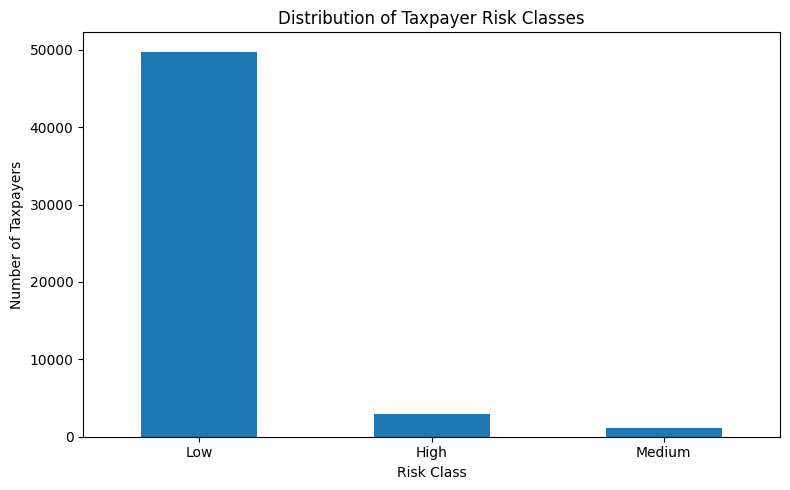

<Figure size 1000x600 with 0 Axes>

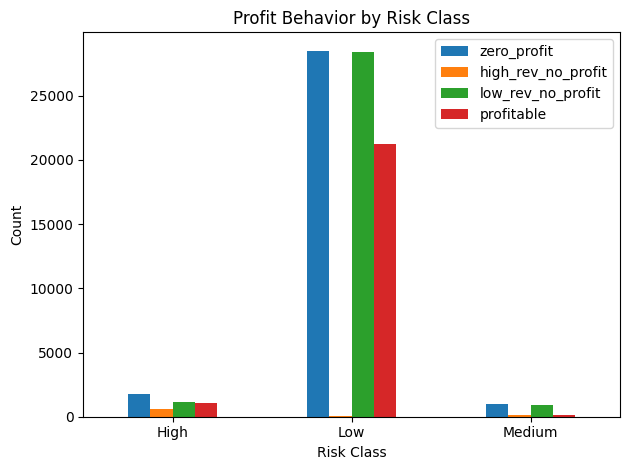

<Figure size 1200x600 with 0 Axes>

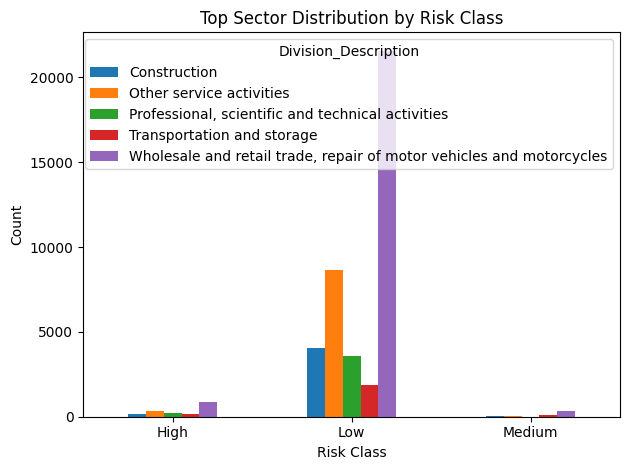

<Figure size 1200x600 with 0 Axes>

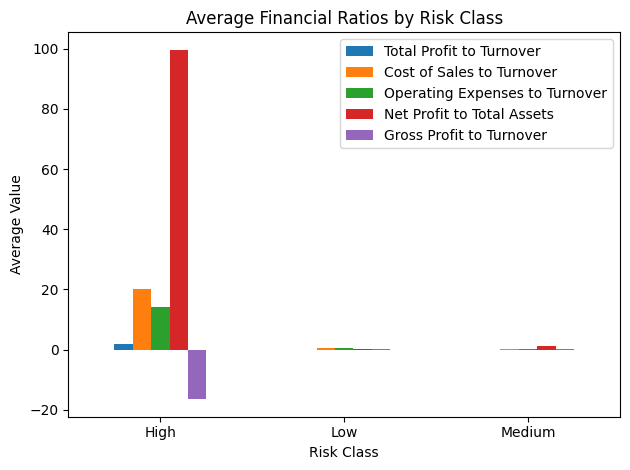

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define paths for self-containment
final_data = '/content/drive/MyDrive/Datasets/Final_with_subsector_percentiles_60_85.csv'
extract_path = '/content/drive/MyDrive/Datasets/Financial_data'

# Load dataset
df = pd.read_csv(final_data)

# Create helper columns
df["zero_profit"] = (df["Total Profit"] == 0).astype(int)
df["high_rev_no_profit"] = (
    (df["Total Profit"] == 0) & (df["Revenue"] >= 500_000_000)
).astype(int)
df["low_rev_no_profit"] = (
    (df["Total Profit"] == 0) & (df["Revenue"] < 500_000_000)
).astype(int)
df["profitable"] = (df["Total Profit"] > 0).astype(int)

# -------------------------------
# Chart 1: Distribution of risk classes
# -------------------------------
risk_dist = df["Subsector_Risk_Class_60_85"].value_counts()

plt.figure(figsize=(8, 5))
risk_dist.plot(kind="bar")
plt.title("Distribution of Taxpayer Risk Classes")
plt.xlabel("Risk Class")
plt.ylabel("Number of Taxpayers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(extract_path, "risk_distribution.png"))
plt.show()

# -------------------------------
# Chart 2: Profit behavior by risk class
# -------------------------------
profit_summary = df.groupby("Subsector_Risk_Class_60_85")[
    ["zero_profit", "high_rev_no_profit", "low_rev_no_profit", "profitable"]
].sum()

plt.figure(figsize=(10, 6))
profit_summary.plot(kind="bar")
plt.title("Profit Behavior by Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(extract_path, "profit_behavior.png"))
plt.show()

# -------------------------------
# Chart 3: Top sector distribution by risk class
# -------------------------------
sector_dist = (
    df.groupby(["Subsector_Risk_Class_60_85", "Division_Description"])
    .size()
    .reset_index(name="count")
)

top_sectors = df["Division_Description"].value_counts().head(5).index
sector_filtered = sector_dist[sector_dist["Division_Description"].isin(top_sectors)]

pivot_sector = sector_filtered.pivot(
    index="Subsector_Risk_Class_60_85",
    columns="Division_Description",
    values="count"
).fillna(0)

plt.figure(figsize=(12, 6))
pivot_sector.plot(kind="bar")
plt.title("Top Sector Distribution by Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(extract_path, "sector_distribution.png"))
plt.show()

# -------------------------------
# Chart 4: Average financial ratios by risk class
# -------------------------------
ratio_cols = [
    "Total Profit to Turnover",
    "Cost of Sales to Turnover",
    "Operating Expenses to Turnover",
    "Net Profit to Total Assets",
    "Gross Profit to Turnover",
]

ratio_summary = df.groupby("Subsector_Risk_Class_60_85")[ratio_cols].mean()

plt.figure(figsize=(12, 6))
ratio_summary.plot(kind="bar")
plt.title("Average Financial Ratios by Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(extract_path, "ratio_summary.png"))
plt.show()

# Final Model Evaluation Summary

1. Objective

The objective of this study was to develop a data-driven approach for identifying high-risk taxpayers using financial ratios, sector-specific benchmarking, and machine learning techniques.

2. Methodology Overview

Data Selection

Year: 2024
Segmentation: Subsector level
Rationale: Financial behavior varies across industries, enabling fair comparison among similar taxpayers

Exploratory Data Analysis (EDA)

Presence of zero revenue and zero profit cases
High revenue with zero profit identified as a key anomaly
Significant variation across subsectors
Skewed distributions and outliers observed

Benchmark Construction

Mean and standard deviation computed per subsector
Zero-profit entities excluded for stability
Ratios used: profitability, cost structure, liquidity, and efficiency

Risk Scoring (Rule-Based Layer)

Z-scores computed for each ratio
Deviations classified into low, medium, and high
Scores assigned (1–3 scale)
Additional penalties applied for:
High revenue with zero profit
Multiple zero ratios

Final Risk Classification

Total risk score computed per taxpayer
Risk classes assigned using subsector-specific percentiles:
Low: ≤ 60th percentile
Medium: 60–85th percentile
High: ≥ 85th percentile

This ensured balanced and fair classification within subsectors.

3. Machine Learning Model
Model: Random Forest Classifier
Features:
Financial ratios (raw values)
Revenue and profit
Sector and subsector
Domain flags: zero_profit_flag, high_rev_no_profit_flag
Target:
Subsector_Risk_Class_60_85 (derived from rule-based scoring)
4. Model Performance
Accuracy: 96.68%

While this indicates very high predictive performance, it must be interpreted with caution.

5. Key Observation

The high accuracy is influenced by structural leakage, as the target variable is derived from the same financial ratios used as input features.

As a result, the model is largely replicating the rule-based system rather than learning independent patterns.

6. Feature Importance Insights

Key drivers of risk include:

Revenue
Profitability ratios (e.g., Gross Profit to Turnover)
Cost structure ratios (e.g., Cost of Sales to Turnover)
Liquidity and equity ratios

Domain insight:

High revenue with zero profit is a strong predictor of risk

Key finding:
Relative financial performance (ratios) is more predictive than absolute values such as profit.

7. Strengths
Sector-aware through subsector benchmarking
Incorporates domain knowledge
Explicitly captures anomaly patterns
Interpretable and scalable
8. Limitations
Structural leakage due to target construction
Limited independence from rule-based logic
No integration of external behavioral signals
No use of temporal (multi-year) trends
9. Justification of Approach

This hybrid framework remains valid, as real-world tax systems often combine rule-based scoring with machine learning to enhance risk detection.

10. Recommendations for Future Work
Improve model independence by using non-derived targets (e.g., audit outcomes)
Incorporate temporal features (year-on-year changes, trends)
Explore advanced models (e.g., XGBoost, LightGBM, anomaly detection)
Expand feature set to include:
Filing behavior
Payment history
Compliance indicators
Final Conclusion

This study demonstrates that combining sector-specific financial benchmarking with machine learning provides a structured approach to taxpayer risk classification. While the current model largely reflects the underlying rule-based system, it establishes a strong foundation for developing more advanced models capable of capturing complex and nonlinear risk patterns.